# TFM "Análisis predictivo de la mortalidad intrahospitalaria por cáncer en Chile (2001-2025)"

Fuente: Departamento de Estadísticas e Información de Salud, Ministerio de Salud Chile.

Alumna: María Magdalena Alegría Villalobos

## 1. Carga y consolidación de datos
Se cargan los 25 archivos anuales de egresos hospitalarios de DEIS (2001-2025), disponibles en Google Drive.

In [ ]:
import pandas as pd
import os

carpeta_principal = '/content/TFM_DEIS_datos'
os.makedirs(carpeta_principal, exist_ok=True)

print("Carpeta de trabajo creada correctamente:")
print(carpeta_principal)

Carpeta de trabajo creada correctamente:
/content/TFM_DEIS_datos


In [ ]:
!pip install gdown --quiet

import gdown
import os

archivos_drive = {
    2001: ("EGRE_DATOS_ABIERTOS_2001.csv", "1yLmelNYOtD0tjknlWL77L7chZFu4lhF-"),
    2002: ("EGRE_DATOS_ABIERTOS_2002.csv", "1uq3J34rJ1wmzGrvKeqz4GQNO49K5ci7X"),
    2003: ("EGRE_DATOS_ABIERTOS_2003.csv", "13yzPMBrKblpOV-iSnHNBm0UFyehZCD3Y"),
    2004: ("EGRE_DATOS_ABIERTOS_2004.csv", "1Wt8512CzAFRfQh5YQjsB6xe6xiv4SIp4"),
    2005: ("EGRE_DATOS_ABIERTOS_2005.csv", "1cuj7RjnhYEP0T_B-JcWXldsfIp2WwTvj"),
    2006: ("EGRE_DATOS_ABIERTOS_2006.csv", "1PIvhd6gl9r7GJuNdnGbJcKHXDE39QbAv"),
    2007: ("EGRE_DATOS_ABIERTOS_2007.csv", "1-hisOXacTRfAMhCeMJKDsAYmJWPif4HA"),
    2008: ("EGRE_DATOS_ABIERTOS_2008.csv", "108eCSySSa0B-zivnbjoUiWwp6KKvgl9C"),
    2009: ("EGRE_DATOS_ABIERTOS_2009.csv", "1ua7lsmiab2RTtXEXccttPUwUoj9rljfY"),
    2010: ("EGRE_DATOS_ABIERTOS_2010.csv", "1XxWXc2Jc1_SsOuidQjy-O3M04avYyGVd"),
    2011: ("EGRE_DATOS_ABIERTOS_2011.csv", "19eJsQeX17v3SwLwWA-1aX9UPP-ZLgk0y"),
    2012: ("EGRESOS_2012.csv", "11oNj_mlGIYEHTiV8MSFKavgZh7oSeg9h"),
    2013: ("EGRE_DATOS_ABIERTOS_2013.csv", "1C_UEL0aLX7yaGG6pTbVLSoGqaWBFSW60"),
    2014: ("EGRE_DATOS_ABIERTOS_2014.csv", "1VblzJxQorG4uX-t2E8JksRZhGn6Njqeq"),
    2015: ("EGRE_DATOS_ABIERTOS_2015.csv", "1oaRoj4SvnbWIgJURFLqaW5LM1UT8VTUc"),
    2016: ("EGRE_DATOS_ABIERTOS_2016.csv", "17w1ktfR27DiU4-7Wnoihf7pntPS2i1f_"),
    2017: ("EGRE_DATOS_ABIERTOS_2017.csv", "1LtQAEPgrgjeXuB0VXStR8v38k4Jen0FT"),
    2018: ("EGRE_DATOS_ABIERTOS_2018.csv", "1eiaG-Qn0rCkGSL4b24dIn7dTm-Bmucy5"),
    2019: ("EGRE_DATOS_ABIERTOS_2019.csv", "1to2_vxhtx56JHbfh_n4vIUJwmBiHmOVJ"),
    2020: ("EGRE_DATOS_ABIERTOS_2020.csv", "1ZwWh7XL1HFs1dGrALETSiL_QxB9Jh0fQ"),
    2021: ("EGR_DATOS_ABIERTO_2021.csv", "167AHXmy-yEkGCDodXAQJ1ZKa1otNPisv"),
    2022: ("EGRE_DATOS_ABIERTOS_2022.csv", "1HZGJ_PbqyPh2t9hBLsxfmXarYwsOUI-G"),
    2023: ("EGRESOS_2023.csv", "1RAOFk_tOVgHqHctrVg5G8bRZgRR_B5Im"),
    2024: ("EGR_DATOS_ABIERTO_2024.csv", "1H5HR-xtcRRJ90yNzP63EFpITscNqxE4e"),
    2025: ("EGR_DATOS_ABIERTO_2025.csv", "1pFWc-JaVHu6C70WL0QCaMtwKH09MjETM"),
}

print("Descargando archivos de egresos DEIS...")

for año, (nombre, file_id) in archivos_drive.items():

    ruta = os.path.join(carpeta_principal, nombre)

    if os.path.exists(ruta):
        print(f"{año}: ya disponible")
        continue

    print(f"{año}: descargando {nombre}")

    gdown.download(
        id=file_id,
        output=ruta,
        quiet=True
    )

print("\nDescarga terminada.")

Descargando archivos de egresos DEIS...
2001: ya disponible
2002: ya disponible
2003: ya disponible
2004: ya disponible
2005: ya disponible
2006: ya disponible
2007: ya disponible
2008: ya disponible
2009: ya disponible
2010: ya disponible
2011: ya disponible
2012: ya disponible
2013: ya disponible
2014: ya disponible
2015: ya disponible
2016: ya disponible
2017: ya disponible
2018: ya disponible
2019: ya disponible
2020: ya disponible
2021: ya disponible
2022: ya disponible
2023: ya disponible
2024: ya disponible
2025: ya disponible

Descarga terminada.


In [ ]:
import re

todos_los_archivos = os.listdir(carpeta_principal)

archivos_crudos = []

for nombre in todos_los_archivos:
    if nombre.endswith('.csv'):
        match = re.search(r'(20[0-2][0-9])', nombre)
        if match:
            año = int(match.group(1))
            if 2001 <= año <= 2025:
                archivos_crudos.append((año, nombre))

archivos_crudos.sort()

print(f"Archivos crudos encontrados: {len(archivos_crudos)}")
for año, nombre in archivos_crudos:
    print(f"  {año}: {nombre}")

Archivos crudos encontrados: 25
  2001: EGRE_DATOS_ABIERTOS_2001.csv
  2002: EGRE_DATOS_ABIERTOS_2002.csv
  2003: EGRE_DATOS_ABIERTOS_2003.csv
  2004: EGRE_DATOS_ABIERTOS_2004.csv
  2005: EGRE_DATOS_ABIERTOS_2005.csv
  2006: EGRE_DATOS_ABIERTOS_2006.csv
  2007: EGRE_DATOS_ABIERTOS_2007.csv
  2008: EGRE_DATOS_ABIERTOS_2008.csv
  2009: EGRE_DATOS_ABIERTOS_2009.csv
  2010: EGRE_DATOS_ABIERTOS_2010.csv
  2011: EGRE_DATOS_ABIERTOS_2011.csv
  2012: EGRESOS_2012.csv
  2013: EGRE_DATOS_ABIERTOS_2013.csv
  2014: EGRE_DATOS_ABIERTOS_2014.csv
  2015: EGRE_DATOS_ABIERTOS_2015.csv
  2016: EGRE_DATOS_ABIERTOS_2016.csv
  2017: EGRE_DATOS_ABIERTOS_2017.csv
  2018: EGRE_DATOS_ABIERTOS_2018.csv
  2019: EGRE_DATOS_ABIERTOS_2019.csv
  2020: EGRE_DATOS_ABIERTOS_2020.csv
  2021: EGR_DATOS_ABIERTO_2021.csv
  2022: EGRE_DATOS_ABIERTOS_2022.csv
  2023: EGRESOS_2023.csv
  2024: EGR_DATOS_ABIERTO_2024.csv
  2025: EGR_DATOS_ABIERTO_2025.csv


Se detectan automáticamente los 25 archivos anuales, identificando el año a partir del nombre de cada uno (los nombres de archivo varían entre años: "EGRE_DATOS_ABIERTOS", "EGRESOS", "EGR_DATOS_ABIERTO").

In [ ]:
ruta_2001 = os.path.join(
    carpeta_principal,
    'EGRE_DATOS_ABIERTOS_2001.csv'
)

with open(ruta_2001, 'r', encoding='latin-1') as f:
    for i in range(3):
        print(f.readline())

PERTENENCIA_ESTABLECIMIENTO_SALUD;SEXO;GRUPO_EDAD;ETNIA;GLOSA_PAIS_ORIGEN;COMUNA_RESIDENCIA;GLOSA_COMUNA_RESIDENCIA;REGION_RESIDENCIA;GLOSA_REGION_RESIDENCIA;PREVISION;GLOSA_PREVISION;ANO_EGRESO;DIAG1;DIAG2;DIAS_ESTADA;CONDICION_EGRESO;INTERV_Q;PROCED

No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS;HOMBRE;1 a 9;sin informacion;sin informacion;01101;Iquique;01;De Tarapacá;99;DESCONOCIDO;2001;G563;;1;1;1;

No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS;HOMBRE;1 a 9;sin informacion;sin informacion;01101;Iquique;01;De Tarapacá;99;DESCONOCIDO;2001;J350;;1;1;1;



In [ ]:
df_2001_muestra = pd.read_csv(ruta_2001, sep=';', encoding='latin-1', dtype=str)

print(f"Cantidad de regiones distintas en 2001: {df_2001_muestra['REGION_RESIDENCIA'].nunique()}")
print("\nCodigos y nombres encontrados:")
print(df_2001_muestra[['REGION_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA']].drop_duplicates().sort_values('REGION_RESIDENCIA').to_string(index=False))

Cantidad de regiones distintas en 2001: 17

Codigos y nombres encontrados:
REGION_RESIDENCIA                 GLOSA_REGION_RESIDENCIA
                *                                       *
               01                             De Tarapacá
               02                          De Antofagasta
               03                              De Atacama
               04                             De Coquimbo
               05                           De Valparaíso
               06             Del Libertador B. O'Higgins
               07                               Del Maule
               08                              Del Bíobío
               09                         De La Araucanía
               10                            De Los Lagos
               11  De Aisén del Gral. C. Ibáñez del Campo
               12 De Magallanes y de La Antártica Chilena
               13               Metropolitana de Santiago
               14                             De Los Rí

En el archivo correspondiente a 2001 se identifican 16 códigos regionales que pueden mapearse a la división territorial utilizada en este análisis. Por esta razón, se mantiene una codificación regional homogénea para todo el periodo 2001-2025, sin requerir una armonización adicional por los cambios político-administrativos ocurridos durante el periodo.

In [ ]:
import gc

lista_cancer = []
resumen_carga = []

for año, nombre in archivos_crudos:
    ruta = f"{carpeta_principal}/{nombre}"

    with open(ruta, 'r', encoding='latin-1') as f:
        primera_linea = f.readline()
    separador = ';' if primera_linea.count(';') > primera_linea.count(',') else ','

    try:
        df_año_crudo = pd.read_csv(ruta, sep=separador, encoding='latin-1', dtype=str, low_memory=False)
    except Exception as e:
        print(f"ERROR cargando {año}: {e}")
        continue

    if 'DIAG1' not in df_año_crudo.columns:
        print(f"ADVERTENCIA: {año} no tiene columna DIAG1. Columnas: {list(df_año_crudo.columns)}")
        continue

    df_año_cancer = df_año_crudo[df_año_crudo['DIAG1'].str.startswith('C', na=False)].copy()
    lista_cancer.append(df_año_cancer)
    resumen_carga.append({'año': año, 'total_filas': df_año_crudo.shape[0], 'filas_cancer': df_año_cancer.shape[0]})
    print(f"{año}: {df_año_crudo.shape[0]} filas totales -> {df_año_cancer.shape[0]} de cancer")

    del df_año_crudo
    gc.collect()

print("\nProceso completo para los 25 años.")

2001: 1566188 filas totales -> 51070 de cancer
2002: 1599076 filas totales -> 62037 de cancer
2003: 1599280 filas totales -> 73152 de cancer
2004: 1627748 filas totales -> 74747 de cancer
2005: 1627743 filas totales -> 75281 de cancer
2006: 1637920 filas totales -> 70403 de cancer
2007: 1632888 filas totales -> 68648 de cancer
2008: 1608540 filas totales -> 67722 de cancer
2009: 1682054 filas totales -> 72714 de cancer
2010: 1623875 filas totales -> 70364 de cancer
2011: 1648687 filas totales -> 73024 de cancer
2012: 1670447 filas totales -> 72282 de cancer
2013: 1676936 filas totales -> 73657 de cancer
2014: 1660151 filas totales -> 74795 de cancer
2015: 1671054 filas totales -> 76705 de cancer
2016: 1637265 filas totales -> 81653 de cancer
2017: 1637150 filas totales -> 80991 de cancer
2018: 1669602 filas totales -> 83098 de cancer
2019: 1667180 filas totales -> 85023 de cancer
2020: 1330477 filas totales -> 70058 de cancer
2021: 1467062 filas totales -> 76566 de cancer
2022: 1597118

Se carga cada archivo detectando automáticamente su separador, y se filtra a únicamente los registros con diagnóstico de cáncer (CIE-10 que comienza con "C"), reduciendo cada año de más de 1,5 millones de egresos totales a entre 51.000 y 101.000 casos oncológicos.

In [ ]:
df_todo = pd.concat(lista_cancer, ignore_index=True)
print(f"Total de filas combinadas: {df_todo.shape[0]}")

ruta_respaldo = os.path.join(carpeta_principal, 'respaldo_25anios_crudo.csv.gz')
df_todo.to_csv(ruta_respaldo, index=False, compression='gzip')
print("Respaldo guardado exitosamente.")

Total de filas combinadas: 1913028
Respaldo guardado exitosamente.


## 2. Preparación de los datos

### Edad y sexo
Se unifica la codificación de edad y sexo utilizados por DEIS a lo largo del periodo, corrigiendo caracteres dañados y consolidando categorías (por ejemplo, "DESCONOCIDO" e "INTERSEX (INDETERMINADO)" del campo sexo).

In [ ]:
print("Valores unicos en GRUPO_EDAD (25 anios):")
print(df_todo['GRUPO_EDAD'].unique())

Valores unicos en GRUPO_EDAD (25 anios):
['1 a 9' '10 a 19' '20 a 29' '30 a 39' '40 a 49' '50 a 59' '60 a 69'
 '70 a 79' '80 a 89' '90 y más' 'menor de un año' '*' '45 A 49 AÑOS'
 '20 A 24 AÑOS' '30 A 34 AÑOS' '50 A 54 AÑOS' '55 A 59 AÑOS'
 '65 A 69 AÑOS' '75 A 79 AÑOS' '80 A 84 AÑOS' '1 A 4 AÑOS' '10 A 14 AÑOS'
 '15 A 19 AÑOS' '25 A 29 AÑOS' '35 A 39 AÑOS' '40 A 44 AÑOS' '5 A 9 AÑOS'
 '60 A 64 AÑOS' '70 A 74 AÑOS' '85 A MAS' 'menor a 7 días'
 '28 DIAS A 2 MES' '2 MESES A MENOS DE 1 AÑO' '7 A 27 DIAS' '90 y mï¿½s'
 'menor de un aï¿½o']


In [ ]:
correcciones_edad = {
    '90 y m�s': '90 y más',
    'menor de un a�o': 'menor de un año',
    '90 y mï¿½s': '90 y más',
    'menor de un aï¿½o': 'menor de un año',
}

df_todo['GRUPO_EDAD'] = df_todo['GRUPO_EDAD'].replace(correcciones_edad)

print("Verificacion: quedan caracteres dañados?")
restantes = df_todo[df_todo['GRUPO_EDAD'].str.contains('�|ï¿½', na=False, regex=True)]['GRUPO_EDAD'].unique()
print(restantes)

Verificacion: quedan caracteres dañados?
[]


In [ ]:
mapeo_edad_unico = {
    'menor de un año': 'menor de 1 año',
    '1 a 9': '1 a 9', '10 a 19': '10 a 19', '20 a 29': '20 a 29',
    '30 a 39': '30 a 39', '40 a 49': '40 a 49', '50 a 59': '50 a 59',
    '60 a 69': '60 a 69', '70 a 79': '70 a 79',
    '80 a 89': '80 y más', '90 y más': '80 y más',

    'menor a 7 días': 'menor de 1 año', '7 A 27 DIAS': 'menor de 1 año',
    '28 DIAS A 2 MES': 'menor de 1 año', '2 MESES A MENOS DE 1 AÑO': 'menor de 1 año',
    '1 A 4 AÑOS': '1 a 9', '5 A 9 AÑOS': '1 a 9',
    '10 A 14 AÑOS': '10 a 19', '15 A 19 AÑOS': '10 a 19',
    '20 A 24 AÑOS': '20 a 29', '25 A 29 AÑOS': '20 a 29',
    '30 A 34 AÑOS': '30 a 39', '35 A 39 AÑOS': '30 a 39',
    '40 A 44 AÑOS': '40 a 49', '45 A 49 AÑOS': '40 a 49',
    '50 A 54 AÑOS': '50 a 59', '55 A 59 AÑOS': '50 a 59',
    '60 A 64 AÑOS': '60 a 69', '65 A 69 AÑOS': '60 a 69',
    '70 A 74 AÑOS': '70 a 79', '75 A 79 AÑOS': '70 a 79',
    '80 A 84 AÑOS': '80 y más', '85 A MAS': '80 y más',

    '*': '*',
}

df_todo['GRUPO_EDAD_UNIFICADO'] = df_todo['GRUPO_EDAD'].map(mapeo_edad_unico)

print("Valores sin mapear (deberian ser 0):")
print(df_todo[df_todo['GRUPO_EDAD_UNIFICADO'].isna()]['GRUPO_EDAD'].unique())

print("\nDistribucion de GRUPO_EDAD_UNIFICADO:")
print(df_todo['GRUPO_EDAD_UNIFICADO'].value_counts())

Valores sin mapear (deberian ser 0):
[]

Distribucion de GRUPO_EDAD_UNIFICADO:
GRUPO_EDAD_UNIFICADO
60 a 69           425395
70 a 79           340745
50 a 59           331568
40 a 49           220009
80 y más          142296
30 a 39           126183
1 a 9             103432
10 a 19            81113
20 a 29            72835
*                  65369
menor de 1 año      4083
Name: count, dtype: int64


In [ ]:
print("Valores unicos en SEXO:")
print(df_todo['SEXO'].unique())

Valores unicos en SEXO:
['HOMBRE' 'MUJER' '*' '1' '2' 'DESCONOCIDO' 'INTERSEX (INDETERMINDADO)']


In [ ]:
mapeo_sexo_unico = {
    'HOMBRE': 'HOMBRE',
    'MUJER': 'MUJER',
    '1': 'HOMBRE',
    '2': 'MUJER',
    'DESCONOCIDO': 'NO INFORMADO',
    'INTERSEX (INDETERMINDADO)': 'INTERSEX',
    '*': '*',
}

df_todo['SEXO_UNIFICADO'] = df_todo['SEXO'].map(mapeo_sexo_unico)

print("Valores sin mapear (deberian ser 0):")
print(df_todo[df_todo['SEXO_UNIFICADO'].isna()]['SEXO'].unique())

print("\nDistribucion de SEXO_UNIFICADO:")
print(df_todo['SEXO_UNIFICADO'].value_counts())

Valores sin mapear (deberian ser 0):
[]

Distribucion de SEXO_UNIFICADO:
SEXO_UNIFICADO
MUJER           987084
HOMBRE          859775
*                66160
INTERSEX             5
NO INFORMADO         4
Name: count, dtype: int64


In [ ]:
df_todo['DIAG1_GRUPO'] = df_todo['DIAG1'].str[:3]

print(f"Categorias unicas antes de agrupar (DIAG1): {df_todo['DIAG1'].nunique()}")
print(f"Categorias unicas despues de agrupar (DIAG1_GRUPO): {df_todo['DIAG1_GRUPO'].nunique()}")

print("\nTop 5 grupos por volumen:")
print(df_todo['DIAG1_GRUPO'].value_counts().head())

Categorias unicas antes de agrupar (DIAG1): 479
Categorias unicas despues de agrupar (DIAG1_GRUPO): 89

Top 5 grupos por volumen:
DIAG1_GRUPO
C50    206112
C18    129542
C16    123094
C91    115695
C61     96734
Name: count, dtype: int64


### Diagnóstico oncológico
Se agrupa el diagnóstico principal a los primeros 3 caracteres del CIE-10 (479 → 89 categorías), consolidando subtipos de un mismo órgano. Los cinco diagnósticos más frecuentes son mama, colon, estómago, leucemia linfoide y próstata.

In [ ]:
nombres_region = {
    '01': 'Tarapaca', '02': 'Antofagasta', '03': 'Atacama', '04': 'Coquimbo',
    '05': 'Valparaiso', '06': "O'Higgins", '07': 'Maule', '08': 'Biobio',
    '09': 'La Araucania', '10': 'Los Lagos', '11': 'Aysen', '12': 'Magallanes',
    '13': 'Metropolitana', '14': 'Los Rios', '15': 'Arica y Parinacota', '16': 'Nuble',
}

df_todo['REGION_COD'] = df_todo['REGION_RESIDENCIA'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
df_todo['REGION_NOMBRE'] = df_todo['REGION_COD'].map(nombres_region)

print(f"Cantidad de regiones encontradas: {df_todo['REGION_NOMBRE'].nunique()}")
print("\nDistribucion:")
print(df_todo['REGION_NOMBRE'].value_counts())

Cantidad de regiones encontradas: 16

Distribucion:
REGION_NOMBRE
Metropolitana         786500
Valparaiso            219027
Biobio                162751
La Araucania          119711
Maule                 103887
Los Lagos              92402
O'Higgins              69493
Antofagasta            55447
Coquimbo               54726
Los Rios               54010
Nuble                  42196
Atacama                21908
Arica y Parinacota     18680
Tarapaca               16834
Magallanes             16501
Aysen                   8808
Name: count, dtype: int64


### Región
Se construye un nombre de región limpio a partir del código numérico, evitando inconsistencias de la columna de texto original.

In [ ]:
df_todo['MORTALIDAD_INTRAHOSP'] = (df_todo['CONDICION_EGRESO'].astype(str) == '2').astype(int)

print("Distribucion de mortalidad intrahospitalaria:")
print(df_todo['MORTALIDAD_INTRAHOSP'].value_counts())
print(f"\nPorcentaje de mortalidad intrahospitalaria: {100 * df_todo['MORTALIDAD_INTRAHOSP'].mean():.2f}%")

Distribucion de mortalidad intrahospitalaria:
MORTALIDAD_INTRAHOSP
0    1819512
1      93516
Name: count, dtype: int64

Porcentaje de mortalidad intrahospitalaria: 4.89%


### Variable objetivo: mortalidad intrahospitalaria
Se construye la variable objetivo a partir de la condición de egreso, identificando los casos en que el egreso corresponde a un fallecimiento (4,89% del total).

In [ ]:
df_todo['DIAS_ESTADA'] = pd.to_numeric(df_todo['DIAS_ESTADA'], errors='coerce')

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print("Estadisticas de DIAS_ESTADA:")
print(df_todo['DIAS_ESTADA'].describe())

print(f"\nValores que no se pudieron convertir a numero: {df_todo['DIAS_ESTADA'].isna().sum()}")

Estadisticas de DIAS_ESTADA:
count   1899977.00
mean          7.43
std          36.96
min           1.00
25%           1.00
50%           3.00
75%           8.00
max       17446.00
Name: DIAS_ESTADA, dtype: float64

Valores que no se pudieron convertir a numero: 13051


### Duración de la estancia hospitalaria
Se convierte a formato numérico. Los 13.051 valores no convertibles corresponden a registros con supresión por privacidad (el mismo conjunto de casos que tiene el año de egreso suprimido). Se detecta además un valor máximo irreal (17.446 días), corregido en el siguiente paso.

In [ ]:
filas_no_numericas = df_todo[df_todo['DIAS_ESTADA'].isna()]

print("Filas con DIAS_ESTADA invalido, por año:")
print(filas_no_numericas['ANO_EGRESO'].value_counts().sort_index())

Filas con DIAS_ESTADA invalido, por año:
ANO_EGRESO
*    13051
Name: count, dtype: int64


Se confirma que el 100% de los casos con duración de estancia no numérica (13.051) corresponde exactamente al mismo conjunto de casos con año de egreso suprimido (*), evidenciando que la supresión por privacidad afecta múltiples campos de forma conjunta en un mismo registro.

In [ ]:
TOPE_DIAS = 1825

df_todo['DIAS_ESTADA_ORIGINAL'] = df_todo['DIAS_ESTADA'].copy()

n_afectados = (df_todo['DIAS_ESTADA'] > TOPE_DIAS).sum()
print(f"Casos afectados por el ajuste: {n_afectados}")

df_todo['DIAS_ESTADA'] = df_todo['DIAS_ESTADA'].clip(upper=TOPE_DIAS)

print("\nEstadisticas de DIAS_ESTADA despues del ajuste:")
print(df_todo['DIAS_ESTADA'].describe())

Casos afectados por el ajuste: 27

Estadisticas de DIAS_ESTADA despues del ajuste:
count   1899977.00
mean          7.35
std          15.13
min           1.00
25%           1.00
50%           3.00
75%           8.00
max        1825.00
Name: DIAS_ESTADA, dtype: float64


Se establece un tope de 1.825 días (5 años) para los 27 casos con valores irreales de duración de estancia, preservando el registro original en DIAS_ESTADA_ORIGINAL por si se necesita más adelante.

In [ ]:
ruta_salida = os.path.join(carpeta_principal, 'dataset_consolidado_25anios.csv.gz')
df_todo.to_csv(ruta_salida, index=False, compression='gzip')

print(f"Guardado exitoso: {df_todo.shape[0]} filas, {df_todo.shape[1]} columnas")

Guardado exitoso: 1913028 filas, 29 columnas


In [ ]:
archivo_establecimientos = os.path.join(
    carpeta_principal,
    'establecimientos_20260325.csv'
)

gdown.download(
    id='1KXQdSLA3R0i7_X1dqpL6YnJrE9F9Mp1v',
    output=archivo_establecimientos,
    quiet=False
)

print("\nArchivo de establecimientos descargado:", os.path.exists(archivo_establecimientos))
print("Ruta:", archivo_establecimientos)

Downloading...
From: https://drive.google.com/uc?id=1KXQdSLA3R0i7_X1dqpL6YnJrE9F9Mp1v
To: /content/TFM_DEIS_datos/establecimientos_20260325.csv
100%|██████████| 2.50M/2.50M [00:00<00:00, 211MB/s]


Archivo de establecimientos descargado: True
Ruta: /content/TFM_DEIS_datos/establecimientos_20260325.csv


## 3. Análisis descriptivo (EDA): evolución temporal

Se analiza la evolución del volumen de egresos y de la mortalidad intrahospitalaria a lo largo de los 25 años del periodo estudiado, antes de examinar la relación con las principales variables demográficas, de previsión de salud, territoriales y clínicas disponibles.

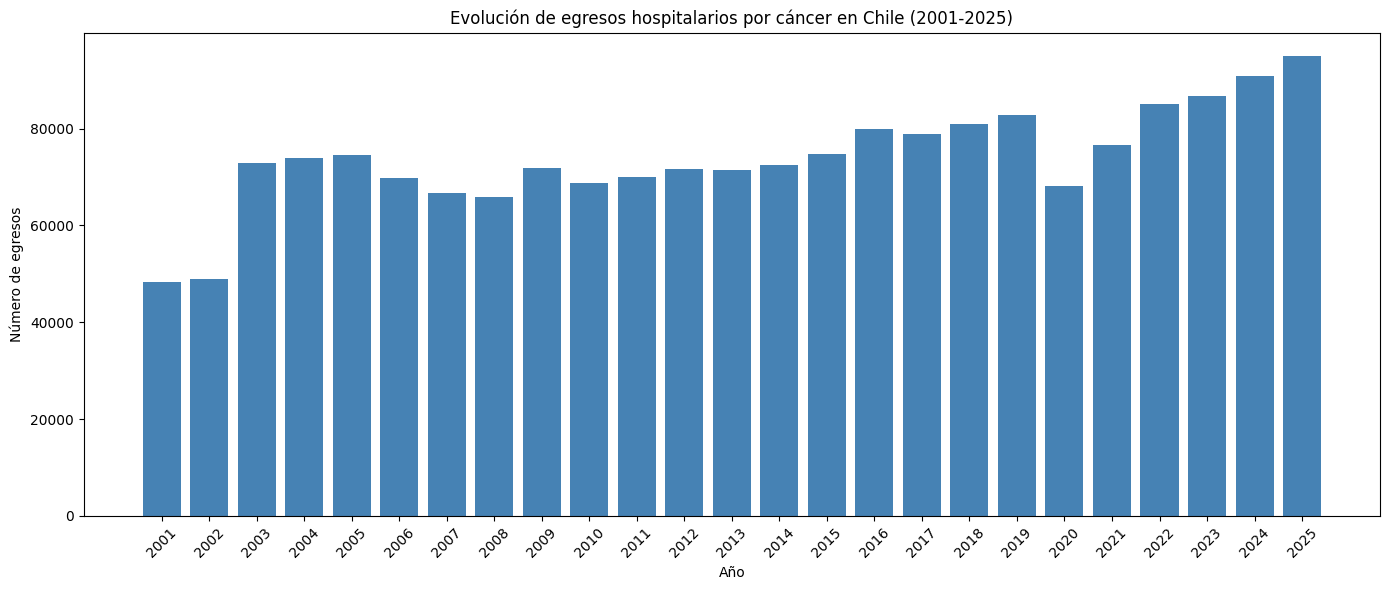

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (14, 6)

df_anual = df_todo[df_todo['ANO_EGRESO'].astype(str) != '*'].copy()
df_anual['ANO_EGRESO'] = df_anual['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False).astype(int)

conteo_anual = df_anual['ANO_EGRESO'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(conteo_anual.index.astype(str), conteo_anual.values, color='steelblue')
ax.set_xlabel('Año')
ax.set_ylabel('Número de egresos')
ax.set_title('Evolución de egresos hospitalarios por cáncer en Chile (2001-2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_anual_diag = df_todo[df_todo['ANO_EGRESO'].astype(str) != '*'].copy()
df_anual_diag['ANO_EGRESO'] = df_anual_diag['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False).astype(int)

In [ ]:
comparacion_regional = df_anual_diag[df_anual_diag['ANO_EGRESO'].isin([2001, 2002, 2003, 2004])].groupby(['ANO_EGRESO', 'REGION_NOMBRE']).size().unstack()
print(comparacion_regional.to_string())

REGION_NOMBRE  Antofagasta  Arica y Parinacota  Atacama  Aysen  Biobio  Coquimbo  La Araucania  Los Lagos  Los Rios  Magallanes  Maule  Metropolitana  Nuble  O'Higgins  Tarapaca  Valparaiso
ANO_EGRESO                                                                                                                                                                                   
2001                  1987                 343      562    228    4513      1633          3489       2090      1539         483   3234          19379   1193       1848       220        5499
2002                  1592                  28      439    144    4641      1197          4132       1925      1206         314   3000          23137   1080       1705        79        4367
2003                  2449                1078      993    308    7314      2237          4870       3035      2208         732   4689          30253   1857       3046       561        7289
2004                  2497                 871    

Entre los registros con año de egreso identificable, el volumen nacional pasó de 48.986 casos en 2002 a 72.919 en 2003, un aumento de aproximadamente 48,9%. El incremento se observa en la mayoría de las regiones y resulta especialmente marcado en el extremo norte: Arica y Parinacota pasó de 28 a 1.078 casos y Tarapacá de 79 a 561. Biobío, la Región Metropolitana y La Araucanía también muestran aumentos relevantes entre ambos años.

In [ ]:
tabla_1_comparacion = comparacion_regional.loc[[2002, 2003], ['Arica y Parinacota', 'Tarapaca', 'Biobio', 'Metropolitana', 'La Araucania']].T
tabla_1_comparacion['variacion_%'] = round(100 * (tabla_1_comparacion[2003] - tabla_1_comparacion[2002]) / tabla_1_comparacion[2002], 0)
tabla_1_comparacion = tabla_1_comparacion.sort_values('variacion_%', ascending=False)

print("Tabla 1. Egresos hospitalarios por cáncer, comparación 2002-2003 en regiones seleccionadas")
print(tabla_1_comparacion.to_string())

Tabla 1. Egresos hospitalarios por cáncer, comparación 2002-2003 en regiones seleccionadas
ANO_EGRESO           2002   2003  variacion_%
REGION_NOMBRE                                
Arica y Parinacota     28   1078      3750.00
Tarapaca               79    561       610.00
Biobio               4641   7314        58.00
Metropolitana       23137  30253        31.00
La Araucania         4132   4870        18.00


La Tabla 1 confirma que el incremento de 2002 a 2003 fue generalizado en el país: Biobío (+58%), Metropolitana (+31%) y La Araucanía (+18%) también muestran aumentos relevantes, aunque de una magnitud muy inferior a la observada en Arica y Parinacota y Tarapacá.

In [ ]:
tabla_tarapaca_anual = df_anual_diag[df_anual_diag['REGION_NOMBRE'] == 'Tarapaca'].groupby('ANO_EGRESO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_tarapaca_anual['mortalidad_intrahosp_%'] = round(100 * tabla_tarapaca_anual['n_fallecidos'] / tabla_tarapaca_anual['n_casos'], 2)

print("Mortalidad intrahospitalaria en Tarapacá, por año:")
print(tabla_tarapaca_anual.to_string(index=False))

Mortalidad intrahospitalaria en Tarapacá, por año:
 ANO_EGRESO  n_casos  n_fallecidos  mortalidad_intrahosp_%
       2001      220             0                    0.00
       2002       79             0                    0.00
       2003      561            10                    1.78
       2004      704            13                    1.85
       2005      756            16                    2.12
       2006      766            26                    3.39
       2007      512            26                    5.08
       2008      437             6                    1.37
       2009      686            31                    4.52
       2010      718            35                    4.87
       2011      857            59                    6.88
       2012      648            42                    6.48
       2013      552            29                    5.25
       2014      644            48                    7.45
       2015      582            47                    8.08
     

La mortalidad intrahospitalaria en Tarapacá muestra una transición gradual entre 2001 y 2010: valores nulos en 2001-2002, sin superar el 5% de forma consistente hasta 2009, y una estabilización en el rango 5-9% a partir de 2010-2011. Este patrón es compatible con una mejora progresiva en la cobertura del registro durante la década de 2000, más que con un cambio real en el riesgo de mortalidad de la población.

 ANO_EGRESO  n_casos  n_fallecidos  mortalidad_intrahosp_%
       2001    48240          2261                    4.69
       2002    48986           718                    1.47
       2003    72919          3395                    4.66
       2004    73937          3401                    4.60
       2005    74605          3461                    4.64
       2006    69742          3470                    4.98
       2007    66730          3658                    5.48
       2008    65832          3579                    5.44
       2009    71746          3839                    5.35
       2010    68836          3628                    5.27
       2011    70085          3635                    5.19
       2012    71724          3828                    5.34
       2013    71479          3924                    5.49
       2014    72407          3771                    5.21
       2015    74742          3992                    5.34
       2016    79854          4154                    5.

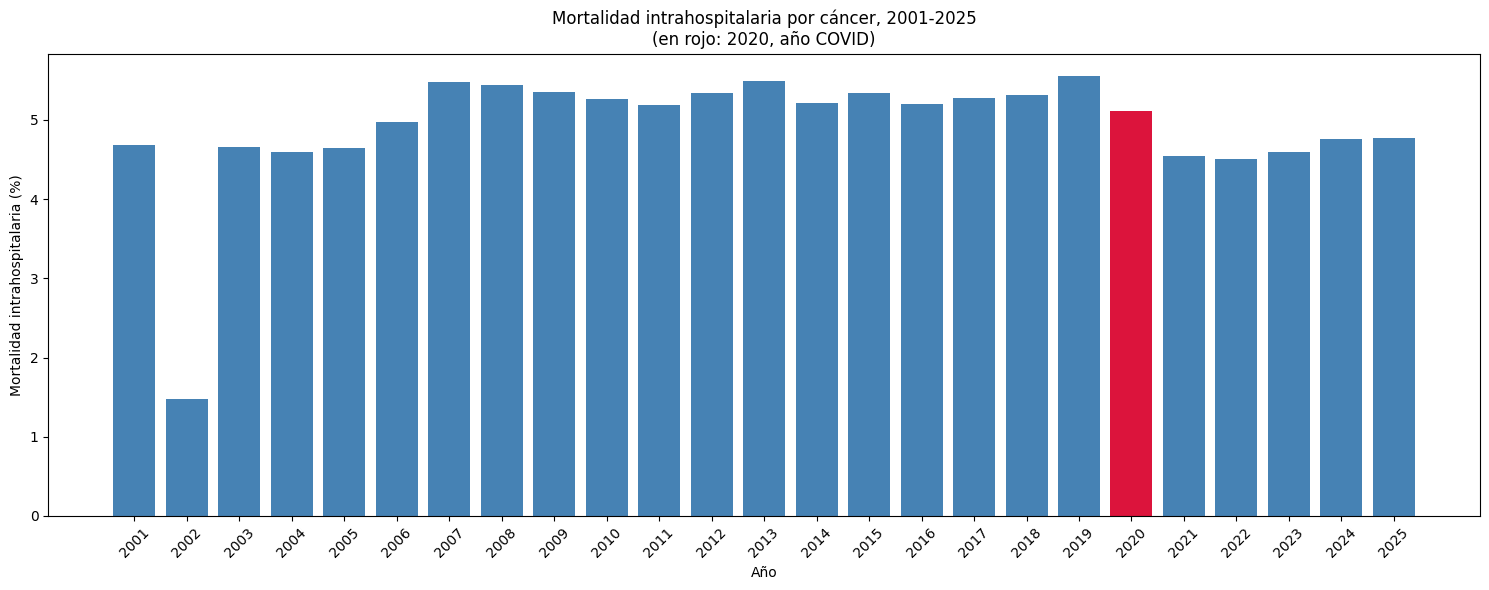

In [ ]:
df_anual_completo = df_todo[df_todo['ANO_EGRESO'].astype(str) != '*'].copy()
df_anual_completo['ANO_EGRESO'] = df_anual_completo['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False).astype(int)

tabla_anual_mortalidad = df_anual_completo.groupby('ANO_EGRESO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index().sort_values('ANO_EGRESO')

tabla_anual_mortalidad['mortalidad_intrahosp_%'] = round(100 * tabla_anual_mortalidad['n_fallecidos'] / tabla_anual_mortalidad['n_casos'], 2)

print(tabla_anual_mortalidad.to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 6))
colores = ['crimson' if año == 2020 else 'steelblue' for año in tabla_anual_mortalidad['ANO_EGRESO']]
ax.bar(tabla_anual_mortalidad['ANO_EGRESO'].astype(str), tabla_anual_mortalidad['mortalidad_intrahosp_%'], color=colores)

ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_xlabel('Año')
ax.set_title('Mortalidad intrahospitalaria por cáncer, 2001-2025\n(en rojo: 2020, año COVID)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La mortalidad intrahospitalaria se mantiene relativamente estable entre 2003 y 2019, en un rango aproximado de 4,6% a 5,6%, con un descenso puntual en 2002 (1,47%) y un quiebre de nivel sostenido a partir de 2021, cuando desciende a aproximadamente 4,5% a 4,8%. En 2020, año de la pandemia, la mortalidad fue de 5,11%, dentro del rango observado durante los años anteriores.

In [ ]:
diversidad_por_año = df_anual_diag.groupby('ANO_EGRESO')['DIAG1'].nunique()
print("Cantidad de codigos DIAG1 distintos usados, por año:")
print(diversidad_por_año)

Cantidad de codigos DIAG1 distintos usados, por año:
ANO_EGRESO
2001    396
2002    389
2003    409
2004    406
2005    403
2006    400
2007    401
2008    402
2009    406
2010    421
2011    432
2012    435
2013    437
2014    435
2015    447
2016    448
2017    444
2018    441
2019    447
2020    441
2021    446
2022    451
2023    451
2024    456
2025    449
Name: DIAG1, dtype: int64


Antes de interpretar el descenso puntual de mortalidad de 2002, se evalúa si podría estar asociado a un cambio en la especificidad del registro clínico. El número de códigos CIE-10 distintos utilizados se mantiene relativamente estable entre 2001 y 2009 (389 a 409), sin observarse una caída anómala en 2002, por lo que este indicador no sugiere una pérdida de especificidad diagnóstica ese año.

In [ ]:
tabla_region = df_todo[df_todo['REGION_NOMBRE'].notna()].groupby('REGION_NOMBRE').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_region['mortalidad_intrahosp_%'] = round(100 * tabla_region['n_fallecidos'] / tabla_region['n_casos'], 2)
tabla_region = tabla_region.sort_values('mortalidad_intrahosp_%', ascending=False)

print(tabla_region.to_string(index=False))

     REGION_NOMBRE  n_casos  n_fallecidos  mortalidad_intrahosp_%
         O'Higgins    69493          4496                    6.47
             Aysen     8808           526                    5.97
        Magallanes    16501           968                    5.87
           Atacama    21908          1274                    5.82
             Nuble    42196          2413                    5.72
            Biobio   162751          9100                    5.59
          Tarapaca    16834           938                    5.57
      La Araucania   119711          6322                    5.28
             Maule   103887          5100                    4.91
     Metropolitana   786500         38046                    4.84
        Valparaiso   219027         10590                    4.84
          Coquimbo    54726          2467                    4.51
         Los Lagos    92402          4012                    4.34
          Los Rios    54010          2305                    4.27
       Ant

A nivel territorial, O'Higgins presenta la mayor mortalidad intrahospitalaria (6,47%), seguida de Aysén (5,97%) y Magallanes (5,87%), mientras que Arica y Parinacota registra la menor (2,97%).

SEXO_UNIFICADO  n_casos  n_fallecidos  mortalidad_intrahosp_%
        HOMBRE   859775         48719                    5.67
         MUJER   987084         42711                    4.33


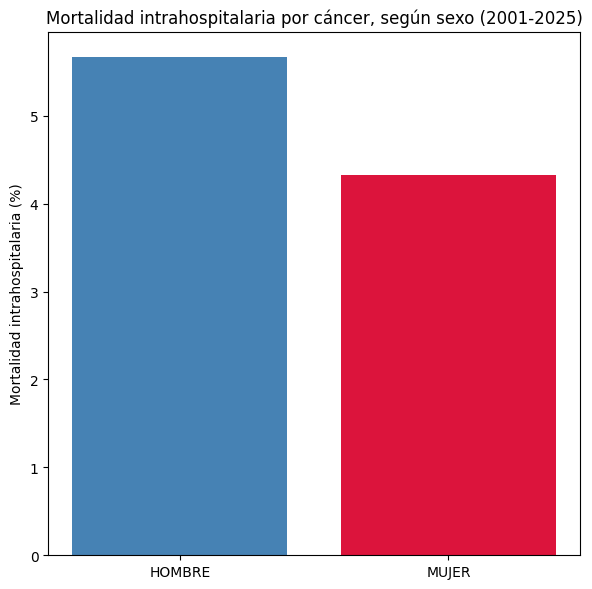

In [ ]:
tabla_sexo = df_todo[df_todo['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER'])].groupby('SEXO_UNIFICADO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_sexo['mortalidad_intrahosp_%'] = round(100 * tabla_sexo['n_fallecidos'] / tabla_sexo['n_casos'], 2)

print(tabla_sexo.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(tabla_sexo['SEXO_UNIFICADO'], tabla_sexo['mortalidad_intrahosp_%'], color=['steelblue', 'crimson'])
ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_title('Mortalidad intrahospitalaria por cáncer, según sexo (2001-2025)')
plt.tight_layout()
plt.show()

GRUPO_EDAD_UNIFICADO  n_casos  n_fallecidos  mortalidad_intrahosp_%
      menor de 1 año     4083            97                    2.38
               1 a 9   103432           805                    0.78
             10 a 19    81113          1125                    1.39
             20 a 29    72835          1640                    2.25
             30 a 39   126183          3160                    2.50
             40 a 49   220009          6664                    3.03
             50 a 59   331568         13994                    4.22
             60 a 69   425395         23069                    5.42
             70 a 79   340745         24823                    7.28
            80 y más   142296         16082                   11.30


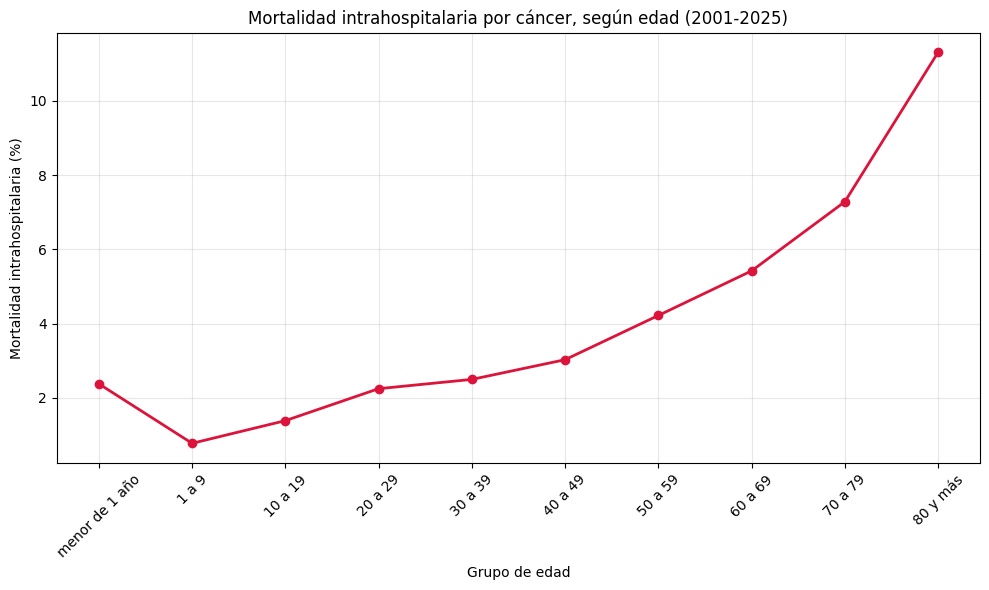

In [ ]:
orden_edad = ['menor de 1 año', '1 a 9', '10 a 19', '20 a 29', '30 a 39',
              '40 a 49', '50 a 59', '60 a 69', '70 a 79', '80 y más']

tabla_edad = df_todo[df_todo['GRUPO_EDAD_UNIFICADO'] != '*'].groupby('GRUPO_EDAD_UNIFICADO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_edad['mortalidad_intrahosp_%'] = round(100 * tabla_edad['n_fallecidos'] / tabla_edad['n_casos'], 2)
tabla_edad['GRUPO_EDAD_UNIFICADO'] = pd.Categorical(tabla_edad['GRUPO_EDAD_UNIFICADO'], categories=orden_edad, ordered=True)
tabla_edad = tabla_edad.sort_values('GRUPO_EDAD_UNIFICADO')

print(tabla_edad.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tabla_edad['GRUPO_EDAD_UNIFICADO'], tabla_edad['mortalidad_intrahosp_%'], marker='o', linewidth=2, color='crimson')
ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_xlabel('Grupo de edad')
ax.set_title('Mortalidad intrahospitalaria por cáncer, según edad (2001-2025)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La mortalidad intrahospitalaria crece de forma sostenida con la edad, desde 0,78% en el grupo de 1 a 9 años hasta 11,30% en mayores de 80 años.

In [ ]:
tabla_prevision = df_todo[df_todo['GLOSA_PREVISION'].notna() & (df_todo['GLOSA_PREVISION'] != '*')].groupby('GLOSA_PREVISION').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_prevision['mortalidad_intrahosp_%'] = round(100 * tabla_prevision['n_fallecidos'] / tabla_prevision['n_casos'], 2)
tabla_prevision = tabla_prevision.sort_values('mortalidad_intrahosp_%', ascending=False)

print(tabla_prevision.to_string(index=False))

GLOSA_PREVISION  n_casos  n_fallecidos  mortalidad_intrahosp_%
         FONASA  1325298         72035                    5.44
        DIPRECA    22095          1124                    5.09
           SISA    26151          1267                    4.84
      CAPREDENA    18606           874                    4.70
        NINGUNA    21400           826                    3.86
    DESCONOCIDO    92586          3480                    3.76
         ISAPRE   340732         11824                    3.47


FONASA presenta mayor mortalidad intrahospitalaria (5,44%) que ISAPRE (3,47%), la brecha de previsión de salud más relevante encontrada en este trabajo.

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(variable):
    datos_validos = df_todo[df_todo[variable].astype(str) != '*']
    tabla = pd.crosstab(datos_validos[variable], datos_validos['MORTALIDAD_INTRAHOSP'])
    chi2_v, p_v, gl_v, esp_v = chi2_contingency(tabla)
    n_v = tabla.sum().sum()
    v = np.sqrt(chi2_v / (n_v * (min(tabla.shape) - 1)))
    return round(v, 4), p_v

variables_a_probar = ['GRUPO_EDAD_UNIFICADO', 'SEXO_UNIFICADO', 'GLOSA_PREVISION', 'REGION_NOMBRE']

resultados = []
for var in variables_a_probar:
    v_cramer, p_valor = cramers_v(var)
    resultados.append({'variable': var, 'V_cramer': v_cramer, 'p_valor': p_valor})

tabla_resumen = pd.DataFrame(resultados).sort_values('V_cramer', ascending=False)
pd.reset_option('display.float_format')
print(tabla_resumen.to_string(index=False))

            variable  V_cramer       p_valor
GRUPO_EDAD_UNIFICADO    0.1215  0.000000e+00
     GLOSA_PREVISION    0.0374  0.000000e+00
      SEXO_UNIFICADO    0.0308  0.000000e+00
       REGION_NOMBRE    0.0246 2.783369e-229


### Jerarquía de asociaciones
Mediante el estadístico V de Cramér se confirma que la edad es, por amplio margen, la variable más asociada a la mortalidad intrahospitalaria, muy por encima de previsión de salud, sexo y región.

In [ ]:
df_cruce = df_todo[
    (df_todo['GLOSA_PREVISION'].isin(['FONASA', 'ISAPRE'])) &
    (df_todo['GRUPO_EDAD_UNIFICADO'] != '*')
].copy()

tabla_cruce = df_cruce.groupby(['GRUPO_EDAD_UNIFICADO', 'GLOSA_PREVISION']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_cruce['mortalidad_intrahosp_%'] = round(100 * tabla_cruce['n_fallecidos'] / tabla_cruce['n_casos'], 2)

orden_edad = ['menor de 1 año', '1 a 9', '10 a 19', '20 a 29', '30 a 39',
              '40 a 49', '50 a 59', '60 a 69', '70 a 79', '80 y más']
tabla_cruce['GRUPO_EDAD_UNIFICADO'] = pd.Categorical(tabla_cruce['GRUPO_EDAD_UNIFICADO'], categories=orden_edad, ordered=True)
tabla_cruce = tabla_cruce.sort_values(['GRUPO_EDAD_UNIFICADO', 'GLOSA_PREVISION'])

print(tabla_cruce.to_string(index=False))

GRUPO_EDAD_UNIFICADO GLOSA_PREVISION  n_casos  n_fallecidos  mortalidad_intrahosp_%
      menor de 1 año          FONASA     3113            80                    2.57
      menor de 1 año          ISAPRE      792            12                    1.52
               1 a 9          FONASA    85743           647                    0.75
               1 a 9          ISAPRE    11120           129                    1.16
             10 a 19          FONASA    66104           917                    1.39
             10 a 19          ISAPRE     9451           146                    1.54
             20 a 29          FONASA    52268          1304                    2.49
             20 a 29          ISAPRE    14600           231                    1.58
             30 a 39          FONASA    84108          2416                    2.87
             30 a 39          ISAPRE    32255           563                    1.75
             40 a 49          FONASA   145968          5020                 

### Previsión de salud y edad
La brecha entre FONASA e ISAPRE se amplía progresivamente con la edad. Es menor en los grupos más jóvenes y alcanza 4,4 puntos porcentuales en las personas de 80 años y más (12,08% frente a 7,67%).

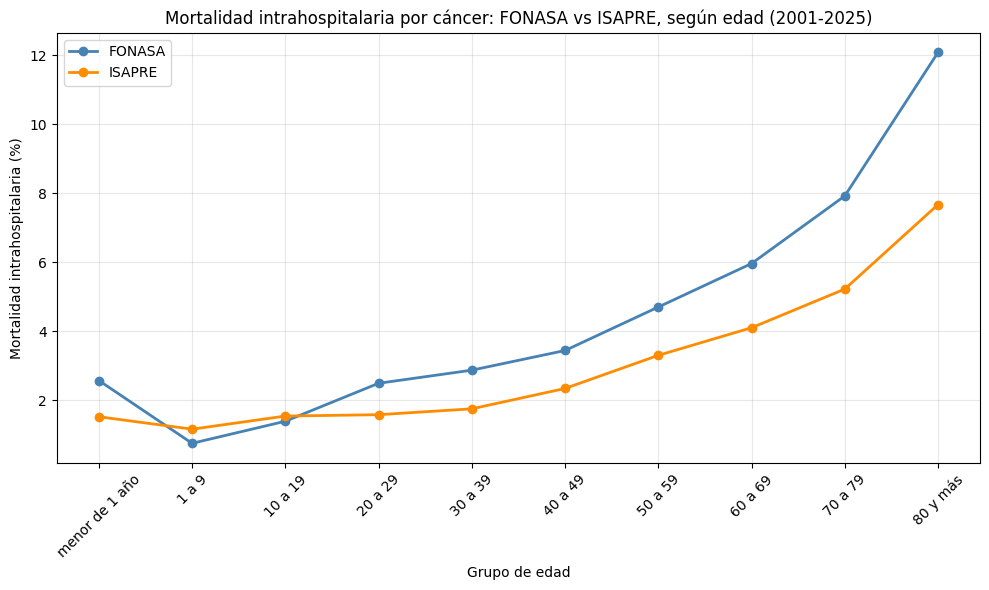

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

for prevision, color in [('FONASA', 'steelblue'), ('ISAPRE', 'darkorange')]:
    datos = tabla_cruce[tabla_cruce['GLOSA_PREVISION'] == prevision]
    ax.plot(datos['GRUPO_EDAD_UNIFICADO'], datos['mortalidad_intrahosp_%'], marker='o', linewidth=2, label=prevision, color=color)

ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_xlabel('Grupo de edad')
ax.set_title('Mortalidad intrahospitalaria por cáncer: FONASA vs ISAPRE, según edad (2001-2025)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
tabla_edad_sexo = df_todo[
    (df_todo['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER'])) &
    (df_todo['GRUPO_EDAD_UNIFICADO'] != '*')
].groupby(['GRUPO_EDAD_UNIFICADO', 'SEXO_UNIFICADO']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_edad_sexo['mortalidad_intrahosp_%'] = round(100 * tabla_edad_sexo['n_fallecidos'] / tabla_edad_sexo['n_casos'], 2)

pivot_edad_sexo = tabla_edad_sexo.pivot(index='GRUPO_EDAD_UNIFICADO', columns='SEXO_UNIFICADO', values='mortalidad_intrahosp_%')
pivot_edad_sexo = pivot_edad_sexo.reindex(orden_edad)

print(pivot_edad_sexo)

SEXO_UNIFICADO        HOMBRE  MUJER
GRUPO_EDAD_UNIFICADO               
menor de 1 año          2.03   2.83
1 a 9                   0.76   0.80
10 a 19                 1.48   1.26
20 a 29                 2.57   1.88
30 a 39                 3.27   2.06
40 a 49                 4.19   2.49
50 a 59                 5.15   3.60
60 a 69                 6.04   4.80
70 a 79                 7.84   6.67
80 y más               11.69  10.92


### Sexo y edad
Los hombres presentan mayor mortalidad que las mujeres en la mayoría de los grupos etarios, con una inversión en menores de 1 año (mujeres 2,83% frente a hombres 2,03%).

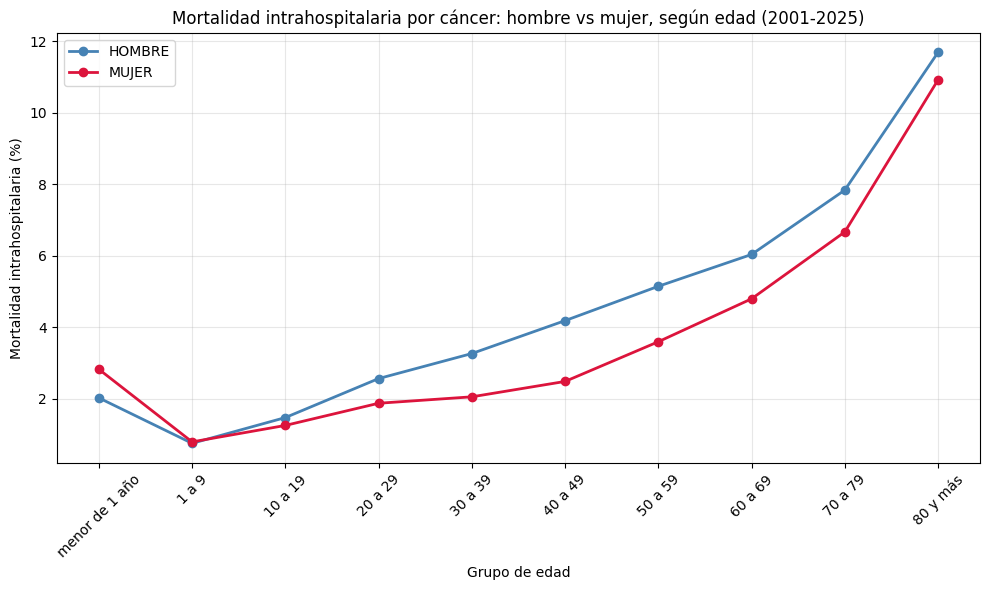

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

for sexo, color in [('HOMBRE', 'steelblue'), ('MUJER', 'crimson')]:
    datos = tabla_edad_sexo[tabla_edad_sexo['SEXO_UNIFICADO'] == sexo]
    datos = datos.set_index('GRUPO_EDAD_UNIFICADO').reindex(orden_edad).reset_index()
    ax.plot(datos['GRUPO_EDAD_UNIFICADO'], datos['mortalidad_intrahosp_%'], marker='o', linewidth=2, label=sexo, color=color)

ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_xlabel('Grupo de edad')
ax.set_title('Mortalidad intrahospitalaria por cáncer: hombre vs mujer, según edad (2001-2025)')
ax.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Regiones encontradas: 16
Celdas ocultadas por tener menos de 30 casos: 1 de 160


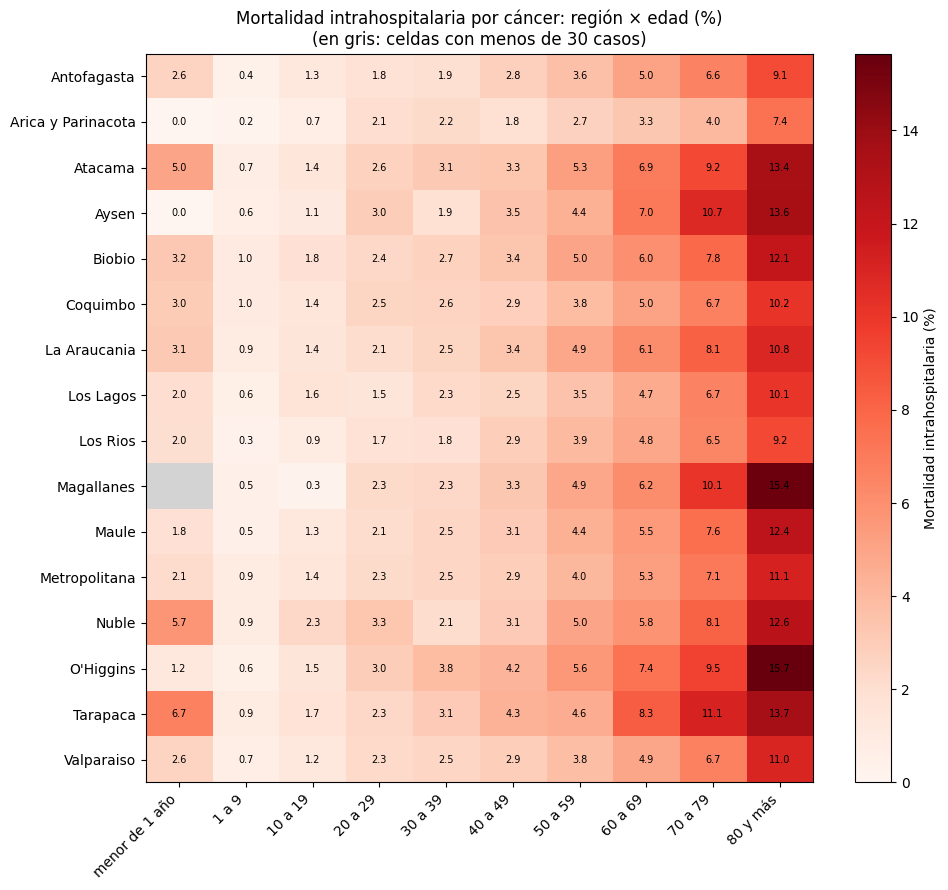

In [ ]:
UMBRAL_MINIMO = 30

tabla_region_edad = df_todo[
    (df_todo['REGION_NOMBRE'].notna()) &
    (df_todo['GRUPO_EDAD_UNIFICADO'] != '*')
].groupby(['REGION_NOMBRE', 'GRUPO_EDAD_UNIFICADO']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_region_edad['mortalidad_intrahosp_%'] = round(100 * tabla_region_edad['n_fallecidos'] / tabla_region_edad['n_casos'], 2)

pivot_mortalidad = tabla_region_edad.pivot(index='REGION_NOMBRE', columns='GRUPO_EDAD_UNIFICADO', values='mortalidad_intrahosp_%')[orden_edad]
pivot_ncasos = tabla_region_edad.pivot(index='REGION_NOMBRE', columns='GRUPO_EDAD_UNIFICADO', values='n_casos')[orden_edad]

pivot_confiable = pivot_mortalidad.where(pivot_ncasos >= UMBRAL_MINIMO)

n_celdas_ocultas = (pivot_ncasos < UMBRAL_MINIMO).sum().sum()
print(f"Regiones encontradas: {pivot_confiable.shape[0]}")
print(f"Celdas ocultadas por tener menos de {UMBRAL_MINIMO} casos: {n_celdas_ocultas} de {pivot_ncasos.size}")

cmap = plt.cm.Reds.copy()
cmap.set_bad('lightgray')

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(pivot_confiable.values, cmap=cmap, aspect='auto')

ax.set_xticks(range(len(pivot_confiable.columns)))
ax.set_xticklabels(pivot_confiable.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_confiable.index)))
ax.set_yticklabels(pivot_confiable.index)

for i in range(len(pivot_confiable.index)):
    for j in range(len(pivot_confiable.columns)):
        valor = pivot_confiable.values[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.1f}", ha='center', va='center', color='black', fontsize=7)

ax.set_title(f'Mortalidad intrahospitalaria por cáncer: región × edad (%)\n(en gris: celdas con menos de {UMBRAL_MINIMO} casos)')
plt.colorbar(im, ax=ax, label='Mortalidad intrahospitalaria (%)')
plt.tight_layout()
plt.show()

### Región y edad
El mapa de calor muestra que las diferencias territoriales persisten al estratificar por edad. La mayoría de las combinaciones región-edad cuenta con al menos 30 casos, ya que solo 1 de 160 celdas queda bajo este umbral.

In [ ]:
tabla_diag_grupo = df_todo.groupby('DIAG1_GRUPO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_diag_grupo['mortalidad_intrahosp_%'] = round(100 * tabla_diag_grupo['n_fallecidos'] / tabla_diag_grupo['n_casos'], 2)
tabla_diag_grupo = tabla_diag_grupo.sort_values('n_casos', ascending=False)

tabla_diag_grupo['pct_del_total'] = round(100 * tabla_diag_grupo['n_casos'] / tabla_diag_grupo['n_casos'].sum(), 2)
tabla_diag_grupo['pct_acumulado'] = round(tabla_diag_grupo['pct_del_total'].cumsum(), 2)

top5_grupo = tabla_diag_grupo.head(5)
print(top5_grupo.to_string(index=False))

DIAG1_GRUPO  n_casos  n_fallecidos  mortalidad_intrahosp_%  pct_del_total  pct_acumulado
        C50   206112          4113                    2.00          10.77          10.77
        C18   129542          5955                    4.60           6.77          17.54
        C16   123094          8908                    7.24           6.43          23.97
        C91   115695          2265                    1.96           6.05          30.02
        C61    96734          3618                    3.74           5.06          35.08


In [ ]:
tabla_diag_grupo[
    tabla_diag_grupo['DIAG1_GRUPO'].isin(['C34', 'C25'])
]

,DIAG1_GRUPO,n_casos,n_fallecidos,mortalidad_intrahosp_%,pct_del_total,pct_acumulado
31,C34,82002,11556,14.09,4.29,43.81
25,C25,40663,4200,10.33,2.13,68.94


In [ ]:
tabla_diag_grupo.sort_values(
    'mortalidad_intrahosp_%',
    ascending=False
).head(15)

,DIAG1_GRUPO,n_casos,n_fallecidos,mortalidad_intrahosp_%,pct_del_total,pct_acumulado
73,C80,7974,1491,18.70,0.42,93.58
31,C34,82002,11556,14.09,4.29,43.81
84,C93,616,80,12.99,0.03,99.91
71,C78,36476,4628,12.69,1.91,76.82
22,C22,29741,3584,12.05,1.55,81.69
26,C26,2730,318,11.65,0.14,97.74
63,C70,968,112,11.57,0.05,99.81
34,C39,314,35,11.15,0.02,100.02
25,C25,40663,4200,10.33,2.13,68.94
24,C24,11585,1147,9.90,0.61,90.96


### Diagnóstico oncológico
Los cinco diagnósticos más frecuentes (mama, colon, estómago, leucemia linfoide y próstata) explican el 35% del total de egresos, pero no coinciden con los de mayor mortalidad.

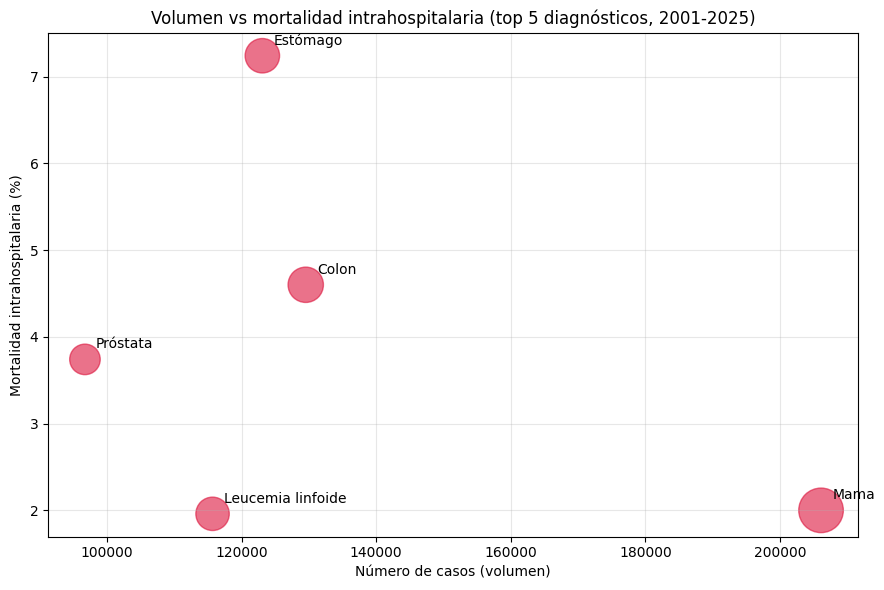

In [ ]:
nombres_diag_grupo = {
    'C50': 'Mama', 'C18': 'Colon', 'C16': 'Estómago',
    'C91': 'Leucemia linfoide', 'C61': 'Próstata'
}

top5_grupo = top5_grupo.copy()
top5_grupo['organo'] = top5_grupo['DIAG1_GRUPO'].map(nombres_diag_grupo)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(top5_grupo['n_casos'], top5_grupo['mortalidad_intrahosp_%'], s=top5_grupo['n_casos']/200, alpha=0.6, color='crimson')

for _, row in top5_grupo.iterrows():
    ax.annotate(row['organo'], (row['n_casos'], row['mortalidad_intrahosp_%']), textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_xlabel('Número de casos (volumen)')
ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_title('Volumen vs mortalidad intrahospitalaria (top 5 diagnósticos, 2001-2025)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_interv_valido = df_todo[
    df_todo['INTERV_Q'].notna() &
    (df_todo['INTERV_Q'].astype(str) != '*')
].copy()

años_con_interv = sorted(df_interv_valido['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False).unique())
print("Años con INTERV_Q disponible:")
print(años_con_interv)

print(f"\nTotal de filas con INTERV_Q valido: {df_interv_valido.shape[0]}")

Años con INTERV_Q disponible:
['*', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']

Total de filas con INTERV_Q valido: 1369261


### Intervención quirúrgica
Se examina si haber sido sometido a una intervención quirúrgica se asocia con la mortalidad intrahospitalaria. La variable está disponible para el periodo 2001-2020 (con la excepción de 2012), cubriendo 1.369.261 registros.

In [ ]:
mapa_interv = {'1': 'Sí tuvo intervención', '2': 'No tuvo intervención'}
df_interv_valido['INTERV_Q_LABEL'] = df_interv_valido['INTERV_Q'].astype(str).str.replace('.0', '', regex=False).map(mapa_interv)

tabla_interv = df_interv_valido.groupby('INTERV_Q_LABEL').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_interv['mortalidad_intrahosp_%'] = round(100 * tabla_interv['n_fallecidos'] / tabla_interv['n_casos'], 2)

print(tabla_interv.to_string(index=False))

      INTERV_Q_LABEL  n_casos  n_fallecidos  mortalidad_intrahosp_%
No tuvo intervención   896160         59034                    6.59
Sí tuvo intervención   473101          9558                    2.02


Se observa una menor mortalidad intrahospitalaria entre quienes tuvieron intervención quirúrgica (2,02% frente a 6,59%). Sin embargo, esta asociación puede estar influida por la selección de pacientes, ya que los casos más avanzados pueden no ser candidatos a cirugía, por lo que el resultado no debe interpretarse como un efecto causal de la intervención.

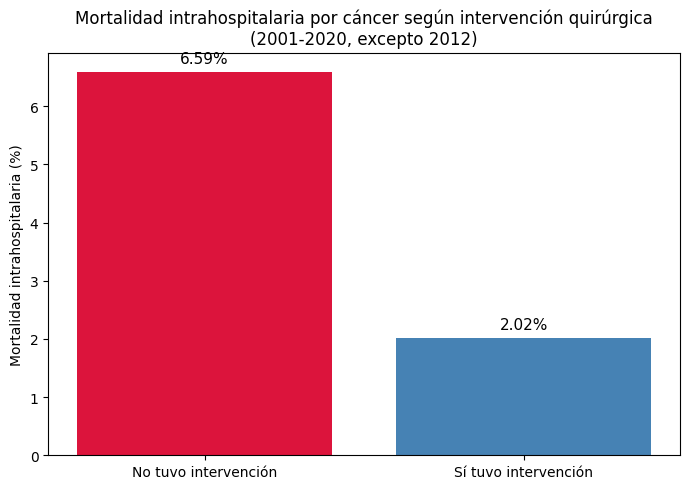

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
colores = ['crimson', 'steelblue']
ax.bar(tabla_interv['INTERV_Q_LABEL'], tabla_interv['mortalidad_intrahosp_%'], color=colores)

for i, valor in enumerate(tabla_interv['mortalidad_intrahosp_%']):
    ax.text(i, valor + 0.15, f"{valor}%", ha='center', fontsize=11)

ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_title('Mortalidad intrahospitalaria por cáncer según intervención quirúrgica\n(2001-2020, excepto 2012)')
plt.tight_layout()
plt.show()

### Análisis complementario a nivel de comuna
Se explora si el nivel de agregación territorial habitual (región) escondía variación relevante a escala más fina.

In [ ]:
UMBRAL_MINIMO_COMUNA = 100

tabla_comuna = df_todo[df_todo['GLOSA_COMUNA_RESIDENCIA'].notna()].groupby('GLOSA_COMUNA_RESIDENCIA').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_comuna['mortalidad_intrahosp_%'] = round(100 * tabla_comuna['n_fallecidos'] / tabla_comuna['n_casos'], 2)

tabla_comuna_top20 = tabla_comuna[tabla_comuna['n_casos'] >= UMBRAL_MINIMO_COMUNA].sort_values('n_casos', ascending=False).head(20)

print(f"Comunas con al menos {UMBRAL_MINIMO_COMUNA} casos: {(tabla_comuna['n_casos'] >= UMBRAL_MINIMO_COMUNA).sum()} de {tabla_comuna.shape[0]} comunas totales")
print()
print(tabla_comuna_top20.sort_values('mortalidad_intrahosp_%', ascending=False).to_string(index=False))

Comunas con al menos 100 casos: 382 de 427 comunas totales

GLOSA_COMUNA_RESIDENCIA  n_casos  n_fallecidos  mortalidad_intrahosp_%
               Rancagua    24943          1548                    6.21
             La Florida    40318          2287                    5.67
                  Ñuñoa    29540          1597                    5.41
             Talcahuano    22067          1191                    5.40
             Valparaíso    42058          2175                    5.17
               Santiago    51632          2612                    5.06
            Puente Alto    49001          2356                    4.81
            Providencia    31109          1466                    4.71
                  Maipú    47818          2196                    4.59
           Viña del Mar    47687          2034                    4.27
             Concepción    29393          1232                    4.19
             Las Condes    66558          2600                    3.91
           Puerto

La columna de nombre de comuna en texto arroja 427 valores distintos, más que las 346 comunas oficiales del país. Se investiga esta discrepancia antes de continuar el análisis.

In [ ]:
UMBRAL_MINIMO_CELDA = 30

comunas_top20 = tabla_comuna_top20['GLOSA_COMUNA_RESIDENCIA'].tolist()

df_comuna_edad = df_todo[
    (df_todo['GLOSA_COMUNA_RESIDENCIA'].isin(comunas_top20)) &
    (df_todo['GRUPO_EDAD_UNIFICADO'] != '*')
].copy()

tabla_comuna_edad = df_comuna_edad.groupby(['GLOSA_COMUNA_RESIDENCIA', 'GRUPO_EDAD_UNIFICADO']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_comuna_edad['mortalidad_intrahosp_%'] = round(100 * tabla_comuna_edad['n_fallecidos'] / tabla_comuna_edad['n_casos'], 2)

pivot_mortalidad_comuna = tabla_comuna_edad.pivot(index='GLOSA_COMUNA_RESIDENCIA', columns='GRUPO_EDAD_UNIFICADO', values='mortalidad_intrahosp_%')[orden_edad]
pivot_ncasos_comuna = tabla_comuna_edad.pivot(index='GLOSA_COMUNA_RESIDENCIA', columns='GRUPO_EDAD_UNIFICADO', values='n_casos')[orden_edad]

pivot_confiable_comuna = pivot_mortalidad_comuna.where(pivot_ncasos_comuna >= UMBRAL_MINIMO_CELDA)

print(pivot_confiable_comuna.loc[['Ñuñoa', 'Las Condes', 'Vitacura']].to_string())

GRUPO_EDAD_UNIFICADO     menor de 1 año  1 a 9  10 a 19  20 a 29  30 a 39  40 a 49  50 a 59  60 a 69  70 a 79  80 y más
GLOSA_COMUNA_RESIDENCIA                                                                                                
Ñuñoa                              5.26   0.38     1.43     1.37     2.19     2.97     3.78     5.47     7.45     12.89
Las Condes                         1.52   1.23     0.94     1.19     2.00     2.15     2.85     3.80     4.93      7.99
Vitacura                            NaN   1.09     0.62     1.40     1.55     1.85     2.54     3.35     4.28      6.91


Al estratificar por edad, la brecha entre Ñuñoa, Las Condes y Vitacura se mantiene y se amplía en las personas de 80 años y más (12,89% frente a 7,99% y 6,91%), evidenciando heterogeneidad territorial incluso dentro de un mismo grupo etario.

In [ ]:
comunas_unicas = sorted(df_todo['GLOSA_COMUNA_RESIDENCIA'].dropna().unique())
print(f"Total de nombres de comuna distintos: {len(comunas_unicas)}")

print("\nBuscando nombres con caracteres dañados:")
dañados = [c for c in comunas_unicas if '�' in c or '?' in c]
print(dañados)

print("\nBuscando ejemplos de nombres parecidos (posibles duplicados):")
print([c for c in comunas_unicas if 'nuñ' in c.lower() or 'nun' in c.lower()])
print([c for c in comunas_unicas if 'valpara' in c.lower()])

Total de nombres de comuna distintos: 427

Buscando nombres con caracteres dañados:
[]

Buscando ejemplos de nombres parecidos (posibles duplicados):
[]
['Valparaíso', 'Valparaï¿½so']


El filtro por el símbolo de daño estándar no detecta los casos reales (que usan la secuencia "ï¿½", no "�"), pero la búsqueda manual confirma el problema: "Valparaíso" y "Valparaï¿½so" comparten el mismo código de comuna pero se registran como nombres de texto distintos, inflando el conteo de 346 a 427.

In [ ]:
codigos_comuna_unicos = df_todo['COMUNA_RESIDENCIA'].dropna().unique()
print(f"Total de codigos de comuna distintos: {len(codigos_comuna_unicos)}")

print("\nCodigos asociados a las dos versiones de Valparaiso:")
print(df_todo[df_todo['GLOSA_COMUNA_RESIDENCIA'].isin(['Valparaíso', 'Valparaï¿½so'])]['COMUNA_RESIDENCIA'].unique())


Total de codigos de comuna distintos: 381

Codigos asociados a las dos versiones de Valparaiso:
['05101']


Se confirma que ambas versiones de "Valparaíso" comparten el mismo código de comuna (05101), validando que el nombre limpio debe construirse a partir del código numérico y no del texto original.

In [ ]:
# Para cada código de comuna se conserva el nombre más frecuente
nombre_mas_comun = df_todo.groupby('COMUNA_RESIDENCIA')['GLOSA_COMUNA_RESIDENCIA'].agg(lambda x: x.value_counts().idxmax())

df_todo['COMUNA_NOMBRE_LIMPIO'] = df_todo['COMUNA_RESIDENCIA'].map(nombre_mas_comun)

print(f"Nombres de comuna limpios distintos: {df_todo['COMUNA_NOMBRE_LIMPIO'].nunique()}")

print("\nVerificacion Valparaiso:")
print(df_todo[df_todo['COMUNA_RESIDENCIA'] == '05101']['COMUNA_NOMBRE_LIMPIO'].unique())

Nombres de comuna limpios distintos: 349

Verificacion Valparaiso:
['Valparaíso']


La limpieza reduce los nombres de comuna de 427 a 349, cercano a las 346 comunas oficiales del país. Valparaíso queda correctamente unificado en una sola versión.

In [ ]:
conteo_por_nombre = df_todo.groupby('COMUNA_NOMBRE_LIMPIO')['COMUNA_RESIDENCIA'].nunique().sort_values(ascending=False)
nombres_con_mas_de_1_codigo = conteo_por_nombre[conteo_por_nombre > 1]

print(f"Nombres limpios que en realidad agrupan más de 1 código distinto: {len(nombres_con_mas_de_1_codigo)}")
print(nombres_con_mas_de_1_codigo)

print("\n--- Códigos y su cantidad de casos, ordenados de menor a mayor (los sospechosos suelen tener pocos casos) ---")
conteo_casos_por_codigo = df_todo.groupby('COMUNA_RESIDENCIA').size().sort_values()
print(conteo_casos_por_codigo.head(15))

Nombres limpios que en realidad agrupan más de 1 código distinto: 32
COMUNA_NOMBRE_LIMPIO
Victoria           2
Temuco             2
Carahue            2
Traiguén           2
Toltén             2
Saavedra           2
Renaico            2
Purén              2
Pucón              2
Pitrufquén         2
Perquenco          2
Padre Las Casas    2
Nueva Imperial     2
Melipeuco          2
Lumaco             2
Los Sauces         2
Lonquimay          2
Loncoche           2
Cholchol           2
Lautaro            2
Gorbea             2
Galvarino          2
Freire             2
Ercilla            2
Curarrehue         2
Curacautín         2
Cunco              2
Collipulli         2
Villarrica         2
Vilcún             2
Teodoro Schmidt    2
Angol              2
Name: COMUNA_RESIDENCIA, dtype: int64

--- Códigos y su cantidad de casos, ordenados de menor a mayor (los sospechosos suelen tener pocos casos) ---
COMUNA_RESIDENCIA
9206      1
9104      2
12402     2
15202     3
12303     5
02202     5

In [ ]:
lista_349 = sorted(df_todo['COMUNA_NOMBRE_LIMPIO'].dropna().unique())
for nombre in lista_349:
    print(nombre)

*
Aisén
Algarrobo
Alhué
Alto Biobío
Alto Hospicio
Alto del Carmen
Ancud
Andacollo
Angol
Antofagasta
Antuco
Antártica
Arauco
Arica
Buin
Bulnes
Cabildo
Cabo de Hornos
Cabrero
Calama
Calbuco
Caldera
Calera
Calera de Tango
Calle Larga
Camarones
Camiña
Canela
Carahue
Cartagena
Casablanca
Castro
Catemu
Cauquenes
Cañete
Cerrillos
Cerro Navia
Chaitén
Chanco
Chañaral
Chiguayante
Chile Chico
Chillán
Chillán Viejo
Chimbarongo
Cholchol
Chonchi
Chépica
Cisnes
Cobquecura
Cochamó
Cochrane
Codegua
Coelemu
Coihaique
Coihueco
Coinco
Colbún
Colchane
Colina
Collipulli
Coltauco
Combarbalá
Concepción
Conchalí
Concón
Constitución
Contulmo
Copiapó
Coquimbo
Coronel
Corral
Cunco
Curacautín
Curacaví
Curaco de Vélez
Curanilahue
Curarrehue
Curepto
Curicó
Dalcahue
Diego de Almagro
Doñihue
El Bosque
El Carmen
El Monte
El Quisco
El Tabo
Empedrado
Ercilla
Estación Central
Extranjero
Florida
Freire
Freirina
Fresia
Frutillar
Futaleufú
Futrono
Galvarino
General Lagos
Gorbea
Graneros
Guaitecas
Hijuelas
Hualaihué
Hualañé
H

In [ ]:
categorias_no_comuna = ['*', 'Extranjero', 'Ignorada']

n_comunas_reales = df_todo[~df_todo['COMUNA_NOMBRE_LIMPIO'].isin(categorias_no_comuna)]['COMUNA_NOMBRE_LIMPIO'].nunique()
print(f"Nombres de comuna reales (excluyendo categorías administrativas): {n_comunas_reales}")

print("\nCasos en cada categoría no-comuna:")
print(df_todo[df_todo['COMUNA_NOMBRE_LIMPIO'].isin(categorias_no_comuna)]['COMUNA_NOMBRE_LIMPIO'].value_counts())

Nombres de comuna reales (excluyendo categorías administrativas): 346

Casos en cada categoría no-comuna:
COMUNA_NOMBRE_LIMPIO
*             20054
Ignorada      10248
Extranjero      317
Name: count, dtype: int64


Los 349 nombres limpios incluyen 3 categorías que no corresponden a comunas reales: "*" (supresión por privacidad, 20.054 casos), "Ignorada" (comuna no registrada, 10.248 casos) y "Extranjero" (residentes fuera de Chile, 317 casos). Al excluirlas, quedan exactamente 346 comunas, coincidiendo con el número oficial del país.

In [ ]:
UMBRAL_MINIMO_COMUNA = 100

tabla_comuna_limpia = df_todo[df_todo['COMUNA_NOMBRE_LIMPIO'].notna()].groupby('COMUNA_NOMBRE_LIMPIO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_comuna_limpia['mortalidad_intrahosp_%'] = round(100 * tabla_comuna_limpia['n_fallecidos'] / tabla_comuna_limpia['n_casos'], 2)

tabla_comuna_top20_limpia = tabla_comuna_limpia[tabla_comuna_limpia['n_casos'] >= UMBRAL_MINIMO_COMUNA].sort_values('n_casos', ascending=False).head(20)

print(f"Comunas con al menos {UMBRAL_MINIMO_COMUNA} casos: {(tabla_comuna_limpia['n_casos'] >= UMBRAL_MINIMO_COMUNA).sum()} de {tabla_comuna_limpia.shape[0]} comunas totales")
print()
print(tabla_comuna_top20_limpia.sort_values('mortalidad_intrahosp_%', ascending=False).to_string(index=False))

Comunas con al menos 100 casos: 330 de 349 comunas totales

COMUNA_NOMBRE_LIMPIO  n_casos  n_fallecidos  mortalidad_intrahosp_%
            Rancagua    24943          1548                    6.21
          La Florida    40318          2287                    5.67
          Talcahuano    22067          1191                    5.40
               Ñuñoa    32618          1755                    5.38
          Valparaíso    46215          2371                    5.13
            Santiago    51632          2612                    5.06
           Peñalolén    24523          1228                    5.01
         Puente Alto    49001          2356                    4.81
         Providencia    31109          1466                    4.71
               Maipú    53456          2445                    4.57
        Viña del Mar    51989          2196                    4.22
          Concepción    33245          1343                    4.04
          Las Condes    66558          2600             

Con los nombres ya limpios, el top 20 se mantiene similar al resultado inicial (Rancagua con la mayor mortalidad, Valdivia con la menor), aunque Peñalolén ahora aparece en la lista, al consolidarse sus casos que antes estaban divididos entre distintas versiones de su nombre.

## 4. Modelización predictiva
Se restringe el análisis al periodo de calidad de registro verificada (2010-2025), dividiendo los datos temporalmente en un conjunto de entrenamiento correspondiente a 2010-2020 y un conjunto de validación temporal correspondiente a 2021-2025.

In [ ]:
columnas_modelo = ['ANO_EGRESO', 'SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                    'GLOSA_PREVISION', 'DIAG1_GRUPO', 'MORTALIDAD_INTRAHOSP']
df_modelo = df_todo[columnas_modelo].copy()

df_modelo['ANO_EGRESO'] = df_modelo['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False)
df_modelo = df_modelo[df_modelo['ANO_EGRESO'] != '*']
df_modelo['ANO_EGRESO'] = df_modelo['ANO_EGRESO'].astype(int)

# Se restringe la modelización al periodo 2010 a 2025
df_modelo = df_modelo[df_modelo['ANO_EGRESO'] >= 2010]

df_modelo = df_modelo[
    df_modelo['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER']) &
    (df_modelo['GRUPO_EDAD_UNIFICADO'] != '*') &
    (df_modelo['GLOSA_PREVISION'].astype(str) != '*') &
    df_modelo['REGION_NOMBRE'].notna()
]

train_df = df_modelo[df_modelo['ANO_EGRESO'] <= 2020].copy()
val_df = df_modelo[df_modelo['ANO_EGRESO'] >= 2021].copy()

print(f"Entrenamiento: {train_df.shape[0]} filas, años {train_df['ANO_EGRESO'].min()}-{train_df['ANO_EGRESO'].max()}")
print(f"Validación: {val_df.shape[0]} filas, años {val_df['ANO_EGRESO'].min()}-{val_df['ANO_EGRESO'].max()}")
print()
print(f"% mortalidad intrahospitalaria en entrenamiento: {100*train_df['MORTALIDAD_INTRAHOSP'].mean():.2f}%")
print(f"% mortalidad intrahospitalaria en validación: {100*val_df['MORTALIDAD_INTRAHOSP'].mean():.2f}%")
print()
print(f"Categorías únicas de diagnóstico agrupado: {train_df['DIAG1_GRUPO'].nunique()}")

Entrenamiento: 819761 filas, años 2010-2020
Validación: 430374 filas, años 2021-2025

% mortalidad intrahospitalaria en entrenamiento: 5.30%
% mortalidad intrahospitalaria en validación: 4.65%

Categorías únicas de diagnóstico agrupado: 89


La proporción de mortalidad intrahospitalaria es levemente distinta entre ambos periodos (5,30% en entrenamiento frente a 4,65% en validación), consistente con el quiebre de nivel observado en el EDA a partir de 2021.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

variables_categoricas = ['SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE', 'GLOSA_PREVISION', 'DIAG1_GRUPO']

X_train = pd.get_dummies(train_df[variables_categoricas], drop_first=True)
X_val = pd.get_dummies(val_df[variables_categoricas], drop_first=True)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['MORTALIDAD_INTRAHOSP']
y_val = val_df['MORTALIDAD_INTRAHOSP']

print(f"Variables después de codificar: {X_train.shape[1]}")

modelo_baseline = LogisticRegression(class_weight='balanced', max_iter=1000)
modelo_baseline.fit(X_train, y_train)

probas_val = modelo_baseline.predict_proba(X_val)[:, 1]
preds_val = modelo_baseline.predict(X_val)

print(f"\nAUC-ROC en validación: {roc_auc_score(y_val, probas_val):.4f}")
print(f"PR-AUC en validación: {average_precision_score(y_val, probas_val):.4f}\n")
print(classification_report(y_val, preds_val, target_names=['Vivo', 'Fallecido']))

Variables después de codificar: 119

AUC-ROC en validación: 0.7277
PR-AUC en validación: 0.1161

              precision    recall  f1-score   support

        Vivo       0.98      0.64      0.77    410358
   Fallecido       0.09      0.70      0.15     20016

    accuracy                           0.64    430374
   macro avg       0.53      0.67      0.46    430374
weighted avg       0.94      0.64      0.75    430374



Se entrena una regresión logística como modelo de referencia (baseline), con balanceo de clases dado el desbalance de la variable objetivo (5,05% de mortalidad). Obtiene un AUC-ROC de 0,7277 y PR-AUC de 0,1161.

In [ ]:
import lightgbm as lgb

modelo_lgbm = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42,
    verbose=-1
)
modelo_lgbm.fit(X_train, y_train)

probas_val_lgbm = modelo_lgbm.predict_proba(X_val)[:, 1]
preds_val_lgbm = modelo_lgbm.predict(X_val)

print(f"AUC-ROC en validación: {roc_auc_score(y_val, probas_val_lgbm):.4f}")
print(f"PR-AUC en validación: {average_precision_score(y_val, probas_val_lgbm):.4f}\n")
print(classification_report(y_val, preds_val_lgbm, target_names=['Vivo', 'Fallecido']))

AUC-ROC en validación: 0.7334
PR-AUC en validación: 0.1200

              precision    recall  f1-score   support

        Vivo       0.98      0.65      0.78    410358
   Fallecido       0.09      0.70      0.16     20016

    accuracy                           0.65    430374
   macro avg       0.53      0.67      0.47    430374
weighted avg       0.94      0.65      0.75    430374



LightGBM obtiene el mejor desempeño de los algoritmos probados hasta ahora, con AUC-ROC de 0,7334 y PR-AUC de 0,1200.

In [ ]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
import xgboost as xgb
from catboost import CatBoostClassifier

modelo_xgb = xgb.XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)
modelo_xgb.fit(X_train, y_train)
probas_val_xgb = modelo_xgb.predict_proba(X_val)[:, 1]

modelo_cat = CatBoostClassifier(
    auto_class_weights='Balanced',
    iterations=200,
    random_state=42,
    verbose=False
)
modelo_cat.fit(X_train, y_train)
probas_val_cat = modelo_cat.predict_proba(X_val)[:, 1]

comparacion = pd.DataFrame({
    'modelo': ['Regresión logística', 'LightGBM', 'XGBoost', 'CatBoost'],
    'AUC_ROC': [
        roc_auc_score(y_val, probas_val),
        roc_auc_score(y_val, probas_val_lgbm),
        roc_auc_score(y_val, probas_val_xgb),
        roc_auc_score(y_val, probas_val_cat),
    ],
    'PR_AUC': [
        average_precision_score(y_val, probas_val),
        average_precision_score(y_val, probas_val_lgbm),
        average_precision_score(y_val, probas_val_xgb),
        average_precision_score(y_val, probas_val_cat),
    ]
})
comparacion = comparacion.sort_values('AUC_ROC', ascending=False)
print(comparacion.to_string(index=False))

             modelo  AUC_ROC   PR_AUC
           LightGBM 0.733410 0.119996
            XGBoost 0.729577 0.118781
           CatBoost 0.728532 0.119243
Regresión logística 0.727703 0.116072


Los cuatro modelos convergen en un rango angosto de desempeño (0,7277 a 0,7334), con LightGBM al frente por un margen mínimo. Esta convergencia sugiere que las variables disponibles en los registros administrativos limitan la capacidad predictiva alcanzable, más allá de las diferencias entre algoritmos. Se selecciona LightGBM como algoritmo de referencia por su leve ventaja en desempeño y su eficiencia computacional.

In [ ]:
nombres_diag_grupo_completo = {
    'C00': 'Labio', 'C01': 'Base de la lengua', 'C02': 'Lengua (otras partes)',
    'C03': 'Encía', 'C04': 'Piso de la boca', 'C05': 'Paladar', 'C06': 'Boca (otras partes)',
    'C07': 'Glándula parótida', 'C08': 'Glándulas salivales', 'C09': 'Amígdala',
    'C10': 'Orofaringe', 'C11': 'Nasofaringe', 'C12': 'Seno piriforme', 'C13': 'Hipofaringe',
    'C14': 'Labio/boca/faringe (otros)',
    'C15': 'Esófago', 'C16': 'Estómago', 'C17': 'Intestino delgado', 'C18': 'Colon',
    'C19': 'Unión rectosigmoidea', 'C20': 'Recto', 'C21': 'Ano',
    'C22': 'Hígado', 'C23': 'Vesícula biliar', 'C24': 'Vías biliares', 'C25': 'Páncreas',
    'C26': 'Digestivo (mal definido)',
    'C30': 'Fosas nasales/oído medio', 'C31': 'Senos paranasales', 'C32': 'Laringe',
    'C33': 'Tráquea', 'C34': 'Pulmón', 'C37': 'Timo', 'C38': 'Corazón/mediastino/pleura',
    'C39': 'Respiratorio (mal definido)',
    'C40': 'Huesos/cartílago (miembros)', 'C41': 'Huesos/cartílago (otros sitios)',
    'C43': 'Melanoma de piel', 'C44': 'Piel (no melanoma)', 'C45': 'Mesotelioma',
    'C46': 'Sarcoma de Kaposi', 'C47': 'Nervios periféricos', 'C48': 'Retroperitoneo/peritoneo',
    'C49': 'Tejido conjuntivo/blando',
    'C50': 'Mama', 'C51': 'Vulva', 'C52': 'Vagina', 'C53': 'Cuello uterino',
    'C54': 'Cuerpo uterino', 'C55': 'Útero (parte no especificada)', 'C56': 'Ovario',
    'C57': 'Genitales femeninos (otros)', 'C58': 'Placenta',
    'C60': 'Pene', 'C61': 'Próstata', 'C62': 'Testículo', 'C63': 'Genitales masculinos (otros)',
    'C64': 'Riñón', 'C65': 'Pelvis renal', 'C66': 'Uréter', 'C67': 'Vejiga',
    'C68': 'Urinario (otros)', 'C69': 'Ojo',
    'C70': 'Meninges', 'C71': 'Encéfalo', 'C72': 'Médula espinal/SNC',
    'C73': 'Tiroides', 'C74': 'Suprarrenal', 'C75': 'Glándulas endocrinas (otras)',
    'C76': 'Sitio mal definido', 'C77': 'Metástasis (ganglios linfáticos)',
    'C78': 'Metástasis (respiratorio/digestivo)', 'C79': 'Metástasis (otros sitios)',
    'C80': 'Sin sitio especificado',
    'C81': 'Linfoma de Hodgkin', 'C82': 'Linfoma folicular no Hodgkin',
    'C83': 'Linfoma difuso no Hodgkin', 'C84': 'Linfoma de células T/NK',
    'C85': 'Linfoma no Hodgkin (otros)', 'C86': 'Linfoma de células T/NK (otros)',
    'C88': 'Enfermedad inmunoproliferativa maligna',
    'C90': 'Mieloma múltiple', 'C91': 'Leucemia linfoide', 'C92': 'Leucemia mieloide',
    'C93': 'Leucemia monocítica', 'C94': 'Leucemia (otro tipo celular)',
    'C95': 'Leucemia (tipo no especificado)', 'C96': 'Tejido linfático/hematopoyético (otros)',
    'C97': 'Tumores malignos de sitios múltiples',
}

def limpiar_nombre_variable(col):
    if col.startswith('DIAG1_GRUPO_'):
        codigo = col.replace('DIAG1_GRUPO_', '')
        return nombres_diag_grupo_completo.get(codigo, codigo)
    elif col.startswith('GRUPO_EDAD_UNIFICADO_'):
        return 'Edad: ' + col.replace('GRUPO_EDAD_UNIFICADO_', '')
    elif col.startswith('SEXO_UNIFICADO_'):
        return 'Sexo: ' + col.replace('SEXO_UNIFICADO_', '').capitalize()
    elif col.startswith('GLOSA_PREVISION_'):
        return 'Previsión: ' + col.replace('GLOSA_PREVISION_', '')
    elif col.startswith('REGION_NOMBRE_'):
        return 'Región: ' + col.replace('REGION_NOMBRE_', '')
    else:
        return col


Se construye un diccionario de nombres legibles para cada código CIE-10, utilizado más adelante para etiquetar los gráficos de interpretabilidad del modelo.

### Códigos CIE-10 sin órgano de origen (C76-C80)
Se identifica que un subconjunto de códigos no representa un órgano de origen, sino la presencia de tumores secundarios (metástasis) o de sitio no especificado, introduciendo una mezcla de lógicas de clasificación distintas dentro de la variable DIAG1_GRUPO.

In [ ]:
codigos_no_origen = ['C76', 'C77', 'C78', 'C79', 'C80']

for codigo in codigos_no_origen:
    n = (df_todo['DIAG1_GRUPO'] == codigo).sum()
    print(f"{codigo}: {n} casos")

total_no_origen = df_todo['DIAG1_GRUPO'].isin(codigos_no_origen).sum()
print(f"\nTotal de casos con diagnostico de tipo 'no-origen': {total_no_origen} de {df_todo.shape[0]} ({100*total_no_origen/df_todo.shape[0]:.2f}%)")

C76: 15634 casos
C77: 4114 casos
C78: 36476 casos
C79: 26695 casos
C80: 7974 casos

Total de casos con diagnostico de tipo 'no-origen': 90893 de 1913028 (4.75%)


Estos códigos afectan a 90.893 casos (4,75% del total). Se evalúa a continuación si su exclusión afecta el desempeño del modelo antes de decidir si se mantienen o se excluyen.

In [ ]:
codigos_no_origen = ['C76', 'C77', 'C78', 'C79', 'C80']

train_df_sin_metastasis = train_df[~train_df['DIAG1_GRUPO'].isin(codigos_no_origen)].copy()
val_df_sin_metastasis = val_df[~val_df['DIAG1_GRUPO'].isin(codigos_no_origen)].copy()

print(f"Entrenamiento sin estos codigos: {train_df_sin_metastasis.shape[0]} filas (antes {train_df.shape[0]})")
print(f"Validacion sin estos codigos: {val_df_sin_metastasis.shape[0]} filas (antes {val_df.shape[0]})")

X_train_sm = pd.get_dummies(train_df_sin_metastasis[variables_categoricas], drop_first=True)
X_val_sm = pd.get_dummies(val_df_sin_metastasis[variables_categoricas], drop_first=True)
X_val_sm = X_val_sm.reindex(columns=X_train_sm.columns, fill_value=0)

y_train_sm = train_df_sin_metastasis['MORTALIDAD_INTRAHOSP']
y_val_sm = val_df_sin_metastasis['MORTALIDAD_INTRAHOSP']

modelo_lgbm_sm = lgb.LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, verbose=-1)
modelo_lgbm_sm.fit(X_train_sm, y_train_sm)

probas_val_sm = modelo_lgbm_sm.predict_proba(X_val_sm)[:, 1]

print(f"\nAUC-ROC CON codigos no-origen (modelo original): {roc_auc_score(y_val, probas_val_lgbm):.4f}")
print(f"AUC-ROC SIN codigos no-origen: {roc_auc_score(y_val_sm, probas_val_sm):.4f}")

Entrenamiento sin estos codigos: 780964 filas (antes 819761)
Validacion sin estos codigos: 410218 filas (antes 430374)

AUC-ROC CON codigos no-origen (modelo original): 0.7334
AUC-ROC SIN codigos no-origen: 0.7314


La exclusión de estos códigos no afecta de forma relevante el desempeño del modelo (AUC-ROC 0,7314 frente a 0,7334 incluyéndolos), una diferencia de apenas 0,002. Se adopta la versión sin estos códigos (`modelo_lgbm_sm`) como modelo definitivo, priorizando la coherencia conceptual de la variable por sobre una mejora marginal en el desempeño.

Como limitación metodológica, el periodo 2021-2025 se utiliza como conjunto de validación temporal tanto para comparar algoritmos como para evaluar algunas decisiones de modelado. Por ello, sus métricas deben interpretarse como desempeño de validación y no como estimación obtenida sobre un conjunto de prueba final completamente independiente.

### Análisis multivariable: regresión logística

Se complementa el análisis con una regresión logística multivariable, que permite estimar la asociación de cada variable con la mortalidad intrahospitalaria ajustando por las demás variables incluidas en el modelo. Para facilitar la interpretación, se utiliza ISAPRE como categoría de referencia para previsión de salud y MUJER como referencia para sexo. Los resultados se expresan mediante odds ratios (OR) e intervalos de confianza del 95%.

In [ ]:
import statsmodels.api as sm

variables_categoricas_ref = train_df_sin_metastasis[variables_categoricas].copy()

# ISAPRE se utiliza como categoría de referencia
variables_categoricas_ref['GLOSA_PREVISION'] = pd.Categorical(
    variables_categoricas_ref['GLOSA_PREVISION'],
    categories=['ISAPRE'] + sorted([
        c for c in variables_categoricas_ref['GLOSA_PREVISION'].dropna().unique()
        if c != 'ISAPRE'
    ])
)

# MUJER se utiliza como categoría de referencia
variables_categoricas_ref['SEXO_UNIFICADO'] = pd.Categorical(
    variables_categoricas_ref['SEXO_UNIFICADO'],
    categories=['MUJER', 'HOMBRE']
)

X_train_logit = pd.get_dummies(
    variables_categoricas_ref,
    drop_first=True
)

X_train_logit_stats = sm.add_constant(
    X_train_logit.astype(float)
)

modelo_logit2 = sm.Logit(
    y_train_sm.astype(float),
    X_train_logit_stats
)

resultado_logit2 = modelo_logit2.fit(maxiter=100)

resumen_or2 = pd.DataFrame({
    'OR': np.exp(resultado_logit2.params),
    'IC_95_inf': np.exp(resultado_logit2.conf_int()[0]),
    'IC_95_sup': np.exp(resultado_logit2.conf_int()[1]),
    'p_valor': resultado_logit2.pvalues
})

variables_interes2 = [
    'GLOSA_PREVISION_FONASA',
    'SEXO_UNIFICADO_HOMBRE',
    'GRUPO_EDAD_UNIFICADO_80 y más',
    'DIAG1_GRUPO_C34'
]

variables_disponibles2 = [
    v for v in variables_interes2
    if v in resumen_or2.index
]

print(resumen_or2.loc[variables_disponibles2].round(4))

Optimization terminated successfully.
         Current function value: 0.179016
         Iterations 9
                                    OR  IC_95_inf  IC_95_sup  p_valor
GLOSA_PREVISION_FONASA          1.5588     1.5111     1.6081      0.0
SEXO_UNIFICADO_HOMBRE           1.1051     1.0794     1.1315      0.0
GRUPO_EDAD_UNIFICADO_80 y más  23.9591    21.3232    26.9209      0.0
DIAG1_GRUPO_C34                14.4901     8.9547    23.4473      0.0


Tras ajustar por edad, sexo, región y diagnóstico, los egresos de beneficiarios FONASA presentan odds de mortalidad intrahospitalaria 56% mayores que los de beneficiarios ISAPRE (OR = 1,56; IC95%: 1,51–1,61; p < 0,001). Los hombres presentan odds 11% mayores que las mujeres (OR = 1,11; IC95%: 1,08–1,13). Las personas de 80 años y más presentan odds considerablemente mayores que el grupo de referencia de 1 a 9 años (OR = 23,96), mientras que el diagnóstico de cáncer de pulmón presenta odds mayores que el diagnóstico de referencia (OR = 14,49). Estos resultados son consistentes con los patrones observados en el análisis descriptivo y permiten evaluar las asociaciones de cada variable ajustando por las demás incluidas en el modelo.


In [ ]:
import shap

muestra_sm = X_val_sm.sample(5000, random_state=42)

explainer_sm = shap.TreeExplainer(modelo_lgbm_sm)
shap_values_sm = explainer_sm.shap_values(muestra_sm)

if isinstance(shap_values_sm, list):
    shap_values_plot_sm = shap_values_sm[1]
else:
    shap_values_plot_sm = shap_values_sm

muestra_sm_legible = muestra_sm.copy()
muestra_sm_legible.columns = [limpiar_nombre_variable(c) for c in muestra_sm_legible.columns]

/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 5. Interpretabilidad del modelo
Se calculan valores SHAP sobre una muestra de 5.000 casos de validación, utilizando el modelo definitivo (sin códigos de metástasis).

In [ ]:
prefijos_demografico = ('GRUPO_EDAD_UNIFICADO_', 'SEXO_UNIFICADO_', 'GLOSA_PREVISION_', 'REGION_NOMBRE_')

columnas_demografico = [c for c in muestra_sm.columns if c.startswith(prefijos_demografico)]
indices_demografico = [muestra_sm.columns.get_loc(c) for c in columnas_demografico]

shap_demografico = shap_values_plot_sm[:, indices_demografico]
muestra_demografico = muestra_sm_legible[[limpiar_nombre_variable(c) for c in columnas_demografico]]

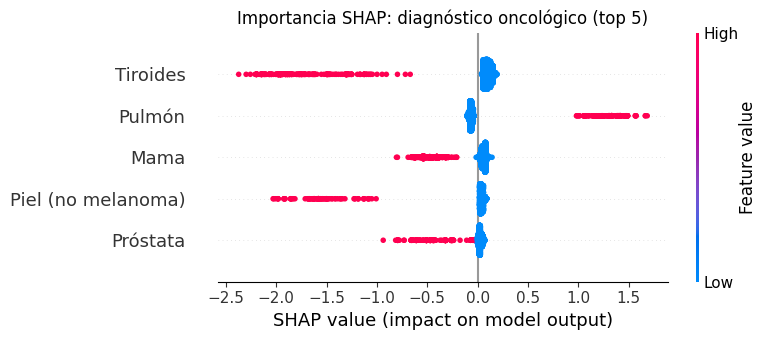

In [ ]:
columnas_diagnostico = [c for c in muestra_sm.columns if c.startswith('DIAG1_GRUPO_')]
indices_diagnostico = [muestra_sm.columns.get_loc(c) for c in columnas_diagnostico]

shap_diagnostico = shap_values_plot_sm[:, indices_diagnostico]
muestra_diagnostico = muestra_sm_legible[[limpiar_nombre_variable(c) for c in columnas_diagnostico]]

shap.summary_plot(shap_diagnostico, muestra_diagnostico, max_display=5, show=False)
plt.title('Importancia SHAP: diagnóstico oncológico (top 5)')
plt.tight_layout()
plt.show()


En el diagnóstico oncológico, los cánceres de tiroides y mama presentan contribuciones asociadas a menor riesgo predicho de mortalidad intrahospitalaria, mientras que el cáncer de pulmón presenta una de las contribuciones asociadas a mayor riesgo. Este patrón es coherente con lo observado en el análisis descriptivo, donde el cáncer de pulmón registra una de las tasas de mortalidad intrahospitalaria más elevadas.

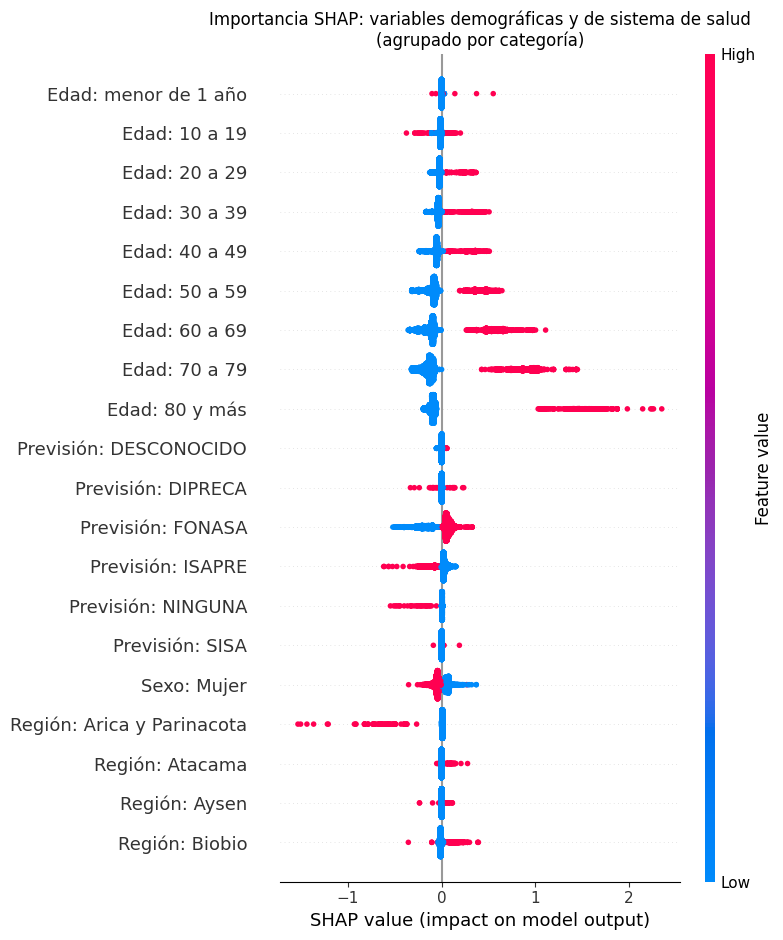

In [ ]:
def categoria_orden(nombre_columna):
    if nombre_columna.startswith('Edad: '):
        edad = nombre_columna.replace('Edad: ', '')
        return (0, orden_edad.index(edad) if edad in orden_edad else 99)
    elif nombre_columna.startswith('Previsión: '):
        return (1, nombre_columna)
    elif nombre_columna.startswith('Sexo: '):
        return (2, nombre_columna)
    elif nombre_columna.startswith('Región: '):
        return (3, nombre_columna)
    else:
        return (4, nombre_columna)

columnas_demografico_legible = list(muestra_demografico.columns)
columnas_ordenadas = sorted(columnas_demografico_legible, key=categoria_orden)
indices_orden = [columnas_demografico_legible.index(c) for c in columnas_ordenadas]

shap_demografico_ordenado = shap_demografico[:, indices_orden]
muestra_demografico_ordenado = muestra_demografico[columnas_ordenadas]

shap.summary_plot(shap_demografico_ordenado, muestra_demografico_ordenado, sort=False, show=False)
plt.title('Importancia SHAP: variables demográficas y de sistema de salud\n(agrupado por categoría)')
plt.tight_layout()
plt.show()

Entre las variables demográficas y de previsión de salud, los grupos de mayor edad presentan las contribuciones más relevantes en las predicciones del modelo, en concordancia con lo observado previamente mediante el estadístico V de Cramér. Las contribuciones SHAP asociadas a FONASA e ISAPRE muestran patrones diferenciados de riesgo predicho, consistentes con la brecha observada en el análisis descriptivo.

## 6. Exposición ambiental
Se cruzan los egresos con comunas bajo declaración ambiental (zonas de sacrificio y Planes de Prevención y/o Descontaminación Atmosférica).

In [ ]:
comunas_ppda_zona_sacrificio = [
    'TOCOPILLA', 'MEJILLONES', 'CALAMA', 'HUASCO', 'ANDACOLLO',
    'CONCON', 'QUINTERO', 'PUCHUNCAVI', 'QUILLOTA', 'CATEMU', 'PANQUEHUE', 'LLAILLAY',
    'CHILLAN', 'CHILLAN VIEJO', 'LOS ANGELES', 'CORONEL',
    'TEMUCO', 'PADRE LAS CASAS', 'VALDIVIA', 'OSORNO', 'COIHAIQUE'
]

df_todo['COMUNA_NORM'] = df_todo['COMUNA_NOMBRE_LIMPIO'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii')

df_todo['ZONA_AMBIENTAL'] = df_todo['COMUNA_NORM'].isin(comunas_ppda_zona_sacrificio).map({True: 'Con declaracion ambiental', False: 'Resto del pais'})

print(df_todo['ZONA_AMBIENTAL'].value_counts())

ZONA_AMBIENTAL
Resto del pais               1720257
Con declaracion ambiental     192771
Name: count, dtype: int64


Esta primera clasificación agrupa 192.771 casos en comunas con declaración ambiental. Se refina a continuación en tres categorías distintas, dado que zona de sacrificio y PPDA ciudad grande representan realidades muy diferentes en cuanto a infraestructura hospitalaria disponible.

In [ ]:
for comuna in comunas_ppda_zona_sacrificio:
    n = (df_todo['COMUNA_NORM'] == comuna).sum()
    print(f"{comuna}: {n} casos")

TOCOPILLA: 2766 casos
MEJILLONES: 752 casos
CALAMA: 13019 casos
HUASCO: 830 casos
ANDACOLLO: 803 casos
CONCON: 3734 casos
QUINTERO: 3197 casos
PUCHUNCAVI: 1358 casos
QUILLOTA: 9810 casos
CATEMU: 1405 casos
PANQUEHUE: 716 casos
LLAILLAY: 2801 casos
CHILLAN: 20310 casos
CHILLAN VIEJO: 927 casos
LOS ANGELES: 19246 casos
CORONEL: 10152 casos
TEMUCO: 40013 casos
PADRE LAS CASAS: 6271 casos
VALDIVIA: 26435 casos
OSORNO: 21980 casos
COIHAIQUE: 6246 casos


Se confirma que las 21 comunas consideradas tienen casos asociados, validando que la variable de exposición ambiental captura efectivamente población de cada una de ellas.

In [ ]:
columnas_modelo_amb = ['ANO_EGRESO', 'SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                        'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL', 'MORTALIDAD_INTRAHOSP']
df_modelo_amb = df_todo[columnas_modelo_amb].copy()

df_modelo_amb['ANO_EGRESO'] = df_modelo_amb['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False)
df_modelo_amb = df_modelo_amb[df_modelo_amb['ANO_EGRESO'] != '*']
df_modelo_amb['ANO_EGRESO'] = df_modelo_amb['ANO_EGRESO'].astype(int)
df_modelo_amb = df_modelo_amb[df_modelo_amb['ANO_EGRESO'] >= 2010]

df_modelo_amb = df_modelo_amb[
    df_modelo_amb['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER']) &
    (df_modelo_amb['GRUPO_EDAD_UNIFICADO'] != '*') &
    (df_modelo_amb['GLOSA_PREVISION'].astype(str) != '*') &
    df_modelo_amb['REGION_NOMBRE'].notna() &
    ~df_modelo_amb['DIAG1_GRUPO'].isin(codigos_no_origen)
]

train_df_amb = df_modelo_amb[df_modelo_amb['ANO_EGRESO'] <= 2020].copy()
val_df_amb = df_modelo_amb[df_modelo_amb['ANO_EGRESO'] >= 2021].copy()

variables_categoricas_amb = ['SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                              'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL']

X_train_amb = pd.get_dummies(train_df_amb[variables_categoricas_amb], drop_first=True)
X_val_amb = pd.get_dummies(val_df_amb[variables_categoricas_amb], drop_first=True)
X_val_amb = X_val_amb.reindex(columns=X_train_amb.columns, fill_value=0)

y_train_amb = train_df_amb['MORTALIDAD_INTRAHOSP']
y_val_amb = val_df_amb['MORTALIDAD_INTRAHOSP']

modelo_lgbm_amb = lgb.LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, verbose=-1)
modelo_lgbm_amb.fit(X_train_amb, y_train_amb)

probas_val_amb = modelo_lgbm_amb.predict_proba(X_val_amb)[:, 1]

print(f"Variables después de codificar: {X_train_amb.shape[1]}")
print(f"\nAUC-ROC CON zona ambiental: {roc_auc_score(y_val_amb, probas_val_amb):.4f}")
print(f"AUC-ROC SIN zona ambiental (modelo anterior): {roc_auc_score(y_val_sm, probas_val_sm):.4f}")

Variables después de codificar: 115

AUC-ROC CON zona ambiental: 0.7321
AUC-ROC SIN zona ambiental (modelo anterior): 0.7314


La incorporación de esta variable ambiental (aún en su versión de 2 categorías) no muestra cambio relevante en el AUC-ROC (0,7321 frente a 0,7314), esperable dado que afecta a un porcentaje acotado de los casos. Se examina a continuación el efecto condicional mediante SHAP, antes de refinar la variable en 3 categorías.

In [ ]:
muestra_amb = X_val_amb.sample(5000, random_state=42)

explainer_amb = shap.TreeExplainer(modelo_lgbm_amb)
shap_values_amb = explainer_amb.shap_values(muestra_amb)

if isinstance(shap_values_amb, list):
    shap_values_plot_amb = shap_values_amb[1]
else:
    shap_values_plot_amb = shap_values_amb

col_zona = 'ZONA_AMBIENTAL_Resto del pais'
idx_col_zona = list(X_train_amb.columns).index(col_zona)

mask_resto_pais = muestra_amb[col_zona] == True

shap_dentro_zona = shap_values_plot_amb[~mask_resto_pais.values, idx_col_zona]
shap_fuera_zona = shap_values_plot_amb[mask_resto_pais.values, idx_col_zona]

print(f"Casos con declaracion ambiental en la muestra: {(~mask_resto_pais).sum()}")
print(f"Valor SHAP promedio DENTRO de zona con declaracion ambiental: {shap_dentro_zona.mean():.4f}")
print(f"Valor SHAP promedio en el RESTO del pais: {shap_fuera_zona.mean():.4f}")

Casos con declaracion ambiental en la muestra: 506
Valor SHAP promedio DENTRO de zona con declaracion ambiental: -0.1523
Valor SHAP promedio en el RESTO del pais: 0.0132


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


El valor SHAP promedio dentro de las comunas con declaración ambiental resulta negativo (-0,1523), sugiriendo inicialmente una contribución hacia menor riesgo predicho. Este resultado puede estar influido por el hecho de que la categoría agrupa territorios con patrones distintos de mortalidad: zonas de sacrificio y comunas PPDA de grandes ciudades. Por esta razón, se refina posteriormente la variable en tres categorías separadas.

In [ ]:
comunas_sacrificio_original = ['QUINTERO', 'PUCHUNCAVI', 'CORONEL', 'MEJILLONES', 'TOCOPILLA', 'HUASCO']
comunas_ppda_nuevas = [c for c in comunas_ppda_zona_sacrificio if c not in comunas_sacrificio_original]

def clasificar_zona(comuna):
    if comuna in comunas_sacrificio_original:
        return 'Zona de sacrificio'
    elif comuna in comunas_ppda_nuevas:
        return 'PPDA ciudad grande'
    else:
        return 'Resto del pais'

df_todo['ZONA_AMBIENTAL_DETALLE'] = df_todo['COMUNA_NORM'].apply(clasificar_zona)
print(df_todo['ZONA_AMBIENTAL_DETALLE'].value_counts())

ZONA_AMBIENTAL_DETALLE
Resto del pais        1720257
PPDA ciudad grande     173716
Zona de sacrificio      19055
Name: count, dtype: int64


Al separar en tres categorías, se distinguen 19.055 casos en zona de sacrificio y 173.716 en PPDA ciudad grande, la misma suma total que la versión anterior (192.771), pero ahora diferenciando dos realidades distintas de exposición ambiental.

In [ ]:
columnas_modelo_amb2 = ['ANO_EGRESO', 'SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                         'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL_DETALLE', 'MORTALIDAD_INTRAHOSP']
df_modelo_amb2 = df_todo[columnas_modelo_amb2].copy()

df_modelo_amb2['ANO_EGRESO'] = df_modelo_amb2['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False)
df_modelo_amb2 = df_modelo_amb2[df_modelo_amb2['ANO_EGRESO'] != '*']
df_modelo_amb2['ANO_EGRESO'] = df_modelo_amb2['ANO_EGRESO'].astype(int)
df_modelo_amb2 = df_modelo_amb2[df_modelo_amb2['ANO_EGRESO'] >= 2010]

df_modelo_amb2 = df_modelo_amb2[
    df_modelo_amb2['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER']) &
    (df_modelo_amb2['GRUPO_EDAD_UNIFICADO'] != '*') &
    (df_modelo_amb2['GLOSA_PREVISION'].astype(str) != '*') &
    df_modelo_amb2['REGION_NOMBRE'].notna() &
    ~df_modelo_amb2['DIAG1_GRUPO'].isin(codigos_no_origen)
]

train_df_amb2 = df_modelo_amb2[df_modelo_amb2['ANO_EGRESO'] <= 2020].copy()
val_df_amb2 = df_modelo_amb2[df_modelo_amb2['ANO_EGRESO'] >= 2021].copy()

variables_categoricas_amb2 = ['SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                               'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL_DETALLE']

X_train_amb2 = pd.get_dummies(train_df_amb2[variables_categoricas_amb2], drop_first=True)
X_val_amb2 = pd.get_dummies(val_df_amb2[variables_categoricas_amb2], drop_first=True)
X_val_amb2 = X_val_amb2.reindex(columns=X_train_amb2.columns, fill_value=0)

y_train_amb2 = train_df_amb2['MORTALIDAD_INTRAHOSP']
y_val_amb2 = val_df_amb2['MORTALIDAD_INTRAHOSP']

modelo_lgbm_amb2 = lgb.LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, verbose=-1)
modelo_lgbm_amb2.fit(X_train_amb2, y_train_amb2)

probas_val_amb2 = modelo_lgbm_amb2.predict_proba(X_val_amb2)[:, 1]

print(f"AUC-ROC con zona ambiental (3 categorias): {roc_auc_score(y_val_amb2, probas_val_amb2):.4f}")
print(f"AUC-ROC modelo sin zona ambiental: {roc_auc_score(y_val_sm, probas_val_sm):.4f}")

AUC-ROC con zona ambiental (3 categorias): 0.7324
AUC-ROC modelo sin zona ambiental: 0.7314


Al incorporar la variable ambiental refinada en 3 categorías, el AUC-ROC no muestra cambio relevante (0,7324 frente a 0,7314), esperable dado que la variable afecta a ~10% de los casos. Se examina a continuación el efecto condicional mediante SHAP, ahora sobre las categorías correctamente diferenciadas.

In [ ]:
muestra_amb2 = X_val_amb2.sample(5000, random_state=42)

explainer_amb2 = shap.TreeExplainer(modelo_lgbm_amb2)
shap_values_amb2 = explainer_amb2.shap_values(muestra_amb2)

if isinstance(shap_values_amb2, list):
    shap_values_plot_amb2 = shap_values_amb2[1]
else:
    shap_values_plot_amb2 = shap_values_amb2

columnas_zona = [c for c in muestra_amb2.columns if c.startswith('ZONA_AMBIENTAL_DETALLE_')]
print("Columnas de zona encontradas:", columnas_zona)

for col in columnas_zona:
    idx = list(X_train_amb2.columns).index(col)
    mask = muestra_amb2[col] == True
    valor_shap = shap_values_plot_amb2[mask.values, idx]
    etiqueta = col.replace('ZONA_AMBIENTAL_DETALLE_', '')
    print(f"\n{etiqueta}: {mask.sum()} casos en la muestra, SHAP promedio = {valor_shap.mean():.4f}")

# Se identifica "PPDA ciudad grande" como categoría de referencia
mask_referencia = ~muestra_amb2[columnas_zona].any(axis=1)
if mask_referencia.sum() > 0:
    print(f"\nCategoria de referencia (ninguna de las anteriores): {mask_referencia.sum()} casos")

Columnas de zona encontradas: ['ZONA_AMBIENTAL_DETALLE_Resto del pais', 'ZONA_AMBIENTAL_DETALLE_Zona de sacrificio']

Resto del pais: 4494 casos en la muestra, SHAP promedio = 0.0173

Zona de sacrificio: 57 casos en la muestra, SHAP promedio = 0.1274

Categoria de referencia (ninguna de las anteriores): 449 casos


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


El análisis condicional muestra un patrón diferenciado: el valor SHAP promedio es de +0,1274 en zona de sacrificio frente a +0,0173 en el resto del país. PPDA ciudad grande actúa como categoría de referencia implícita en la codificación y, por tanto, no dispone de una variable dummy propia en este análisis. Estos resultados sugieren una asociación entre la clasificación ambiental territorial y la mortalidad intrahospitalaria, que debe interpretarse con cautela y en conjunto con la disponibilidad local de infraestructura hospitalaria.

In [ ]:
tabla_zona_amb = df_todo.groupby('ZONA_AMBIENTAL_DETALLE').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_zona_amb['mortalidad_intrahosp_%'] = round(100 * tabla_zona_amb['n_fallecidos'] / tabla_zona_amb['n_casos'], 2)

print(tabla_zona_amb.to_string(index=False))

ZONA_AMBIENTAL_DETALLE  n_casos  n_fallecidos  mortalidad_intrahosp_%
    PPDA ciudad grande   173716          6681                    3.85
        Resto del pais  1720257         85570                    4.97
    Zona de sacrificio    19055          1265                    6.64


Las tasas crudas muestran diferencias entre las categorías territoriales: las zonas de sacrificio presentan la mayor mortalidad intrahospitalaria (6,64%), seguidas del resto del país (4,97%), mientras que las comunas clasificadas como PPDA ciudad grande presentan la menor (3,85%). Estas diferencias son descriptivas y pueden estar relacionadas con múltiples características territoriales y poblacionales, por lo que no permiten establecer un mecanismo causal específico.

### Acceso a infraestructura hospitalaria

Se incorpora un dataset externo del Ministerio de Salud (Establecimientos de Salud) para aproximar la disponibilidad local de infraestructura hospitalaria de alta complejidad a nivel comunal, en lugar de inferirla indirectamente a partir de la clasificación de zonas ambientales.

In [ ]:
ruta_establecimientos = os.path.join(
    carpeta_principal,
    'establecimientos_20260325.csv'
)

with open(ruta_establecimientos, 'r', encoding='utf-8') as f:
    primera_linea = f.readline()

separador_est = ';' if primera_linea.count(';') > primera_linea.count(',') else ','

df_establecimientos = pd.read_csv(
    ruta_establecimientos,
    sep=separador_est,
    encoding='utf-8',
    dtype=str,
    low_memory=False
)

print(f"Total de establecimientos: {df_establecimientos.shape[0]}")
print("\nValores de TipoEstablecimientoGlosa (primeros 5), para verificar tildes:")
print(df_establecimientos['TipoEstablecimientoGlosa'].value_counts().head(5))

Total de establecimientos: 5717

Valores de TipoEstablecimientoGlosa (primeros 5), para verificar tildes:
TipoEstablecimientoGlosa
Posta de Salud Rural (PSR)           1184
Centro de Salud Privado               914
Centro de Salud Familiar (CESFAM)     607
Laboratorio Clínico                   441
Clínica Dental                        358
Name: count, dtype: int64


In [ ]:
print("Valores de NivelComplejidadEstabGlosa:")
print(df_establecimientos['NivelComplejidadEstabGlosa'].value_counts())

print("\nValores de TipoEstablecimientoGlosa (primeros 20):")
print(df_establecimientos['TipoEstablecimientoGlosa'].value_counts().head(20))

print("\nValores de EstadoFuncionamiento:")
print(df_establecimientos['EstadoFuncionamiento'].value_counts())

Valores de NivelComplejidadEstabGlosa:
NivelComplejidadEstabGlosa
Baja Complejidad       3321
Mediana Complejidad    1253
No Aplica               737
Alta Complejidad        131
Name: count, dtype: int64

Valores de TipoEstablecimientoGlosa (primeros 20):
TipoEstablecimientoGlosa
Posta de Salud Rural (PSR)                                               1184
Centro de Salud Privado                                                   914
Centro de Salud Familiar (CESFAM)                                         607
Laboratorio Clínico                                                       441
Clínica Dental                                                            358
Centro Comunitario de Salud Familiar (CECOSF)                             304
Servicio de Atención Primaria de Urgencia (SAPU)                          258
Hospital                                                                  234
Clínica                                                                   198
Otro             

In [ ]:
comunas_con_alta_complejidad = df_establecimientos[
    (df_establecimientos['NivelComplejidadEstabGlosa'] == 'Alta Complejidad') &
    (df_establecimientos['EstadoFuncionamiento'].str.contains('Vigente', case=False, na=False))
]['ComunaGlosa'].unique()

print(f"Comunas con al menos un hospital de Alta Complejidad vigente: {len(comunas_con_alta_complejidad)}")
print(sorted(comunas_con_alta_complejidad))

Comunas con al menos un hospital de Alta Complejidad vigente: 58
['Angol', 'Antofagasta', 'Arica', 'Calama', 'Castro', 'Cerro Navia', 'Chillán', 'Concepción', 'Copiapó', 'Coquimbo', 'Coronel', 'Coyhaique', 'Curicó', 'Estación Central', 'Hualpén', 'Huechuraba', 'Independencia', 'Iquique', 'La Florida', 'La Reina', 'La Serena', 'Las Condes', 'Linares', 'Los Andes', 'Los Ángeles', 'Lota', 'Maipú', 'Melipilla', 'Osorno', 'Ovalle', 'Peñalolén', 'Providencia', 'Puente Alto', 'Puerto Montt', 'Puerto Varas', 'Punta Arenas', 'Quillota', 'Quilpué', 'Rancagua', 'Recoleta', 'San Antonio', 'San Bernardo', 'San Carlos', 'San Felipe', 'San Fernando', 'San Miguel', 'San Ramón', 'Santiago', 'Talca', 'Talcahuano', 'Temuco', 'Tome', 'Valdivia', 'Valparaíso', 'Victoria', 'Vitacura', 'Viña del Mar', 'Ñuñoa']


In [ ]:
comunas_con_alta_complejidad_norm = pd.Series(comunas_con_alta_complejidad).str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii').tolist()

df_todo['TIENE_HOSPITAL_ALTA_COMPLEJIDAD'] = df_todo['COMUNA_NORM'].isin(comunas_con_alta_complejidad_norm)

print(df_todo['TIENE_HOSPITAL_ALTA_COMPLEJIDAD'].value_counts())
print(f"\nPorcentaje de casos en comunas con hospital de alta complejidad: {100*df_todo['TIENE_HOSPITAL_ALTA_COMPLEJIDAD'].mean():.2f}%")

TIENE_HOSPITAL_ALTA_COMPLEJIDAD
True     1203984
False     709044
Name: count, dtype: int64

Porcentaje de casos en comunas con hospital de alta complejidad: 62.94%


### Disponibilidad local de infraestructura hospitalaria

Se construye una variable de disponibilidad local de infraestructura hospitalaria a partir del dataset abierto de Establecimientos de Salud del Ministerio de Salud, identificando si la comuna de residencia del paciente cuenta con al menos un hospital de Alta Complejidad vigente. Esta variable complementa el análisis ambiental anterior, incorporando una aproximación territorial a la disponibilidad de infraestructura hospitalaria sin asumir que equivale al acceso efectivo de cada paciente. Dado que el archivo de establecimientos utilizado corresponde a una versión de 2026, esta variable se interpreta como una aproximación a la disponibilidad territorial de infraestructura y no como una medición histórica de la oferta hospitalaria para cada año del periodo analizado.

In [ ]:
tabla_interaccion = df_todo.groupby(['ZONA_AMBIENTAL_DETALLE', 'TIENE_HOSPITAL_ALTA_COMPLEJIDAD']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_interaccion['mortalidad_intrahosp_%'] = round(100 * tabla_interaccion['n_fallecidos'] / tabla_interaccion['n_casos'], 2)

print(tabla_interaccion.to_string(index=False))

ZONA_AMBIENTAL_DETALLE  TIENE_HOSPITAL_ALTA_COMPLEJIDAD  n_casos  n_fallecidos  mortalidad_intrahosp_%
    PPDA ciudad grande                            False    22903          1165                    5.09
    PPDA ciudad grande                             True   150813          5516                    3.66
        Resto del pais                            False   677238         37290                    5.51
        Resto del pais                             True  1043019         48280                    4.63
    Zona de sacrificio                            False     8903           515                    5.78
    Zona de sacrificio                             True    10152           750                    7.39


In [ ]:
print("Desglose de zona de sacrificio por comuna:")
print(df_todo[df_todo['ZONA_AMBIENTAL_DETALLE'] == 'Zona de sacrificio'].groupby(['COMUNA_NORM', 'TIENE_HOSPITAL_ALTA_COMPLEJIDAD']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).assign(mortalidad_pct=lambda x: round(100*x['n_fallecidos']/x['n_casos'], 2)))

Desglose de zona de sacrificio por comuna:
                                             n_casos  n_fallecidos  \
COMUNA_NORM TIENE_HOSPITAL_ALTA_COMPLEJIDAD                          
CORONEL     True                               10152           750   
HUASCO      False                                830            70   
MEJILLONES  False                                752            41   
PUCHUNCAVI  False                               1358            79   
QUINTERO    False                               3197           152   
TOCOPILLA   False                               2766           173   

                                             mortalidad_pct  
COMUNA_NORM TIENE_HOSPITAL_ALTA_COMPLEJIDAD                  
CORONEL     True                                       7.39  
HUASCO      False                                      8.43  
MEJILLONES  False                                      5.45  
PUCHUNCAVI  False                                      5.82  
QUINTERO    False       

La interacción entre clasificación ambiental y disponibilidad local de infraestructura hospitalaria muestra diferencias descriptivas entre los grupos. En las comunas clasificadas como PPDA ciudad grande, la mortalidad intrahospitalaria es de 3,66% cuando existe al menos un hospital de alta complejidad en la comuna y de 5,09% cuando no existe; en el resto del país, las cifras son 4,63% y 5,51%, respectivamente. En las zonas de sacrificio el patrón se invierte (7,39% frente a 5,78%). Este último resultado debe interpretarse con cautela, ya que, de las seis comunas incluidas en esta categoría, solo Coronel cuenta con un hospital de alta complejidad, por lo que la comparación no permite estimar un efecto generalizable de la disponibilidad hospitalaria en este grupo.

In [ ]:
columnas_modelo_acceso = ['ANO_EGRESO', 'SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                           'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL_DETALLE',
                           'TIENE_HOSPITAL_ALTA_COMPLEJIDAD', 'MORTALIDAD_INTRAHOSP']
df_modelo_acceso = df_todo[columnas_modelo_acceso].copy()

df_modelo_acceso['ANO_EGRESO'] = df_modelo_acceso['ANO_EGRESO'].astype(str).str.replace('.0', '', regex=False)
df_modelo_acceso = df_modelo_acceso[df_modelo_acceso['ANO_EGRESO'] != '*']
df_modelo_acceso['ANO_EGRESO'] = df_modelo_acceso['ANO_EGRESO'].astype(int)
df_modelo_acceso = df_modelo_acceso[df_modelo_acceso['ANO_EGRESO'] >= 2010]

df_modelo_acceso = df_modelo_acceso[
    df_modelo_acceso['SEXO_UNIFICADO'].isin(['HOMBRE', 'MUJER']) &
    (df_modelo_acceso['GRUPO_EDAD_UNIFICADO'] != '*') &
    (df_modelo_acceso['GLOSA_PREVISION'].astype(str) != '*') &
    df_modelo_acceso['REGION_NOMBRE'].notna() &
    ~df_modelo_acceso['DIAG1_GRUPO'].isin(codigos_no_origen)
]

train_df_acceso = df_modelo_acceso[df_modelo_acceso['ANO_EGRESO'] <= 2020].copy()
val_df_acceso = df_modelo_acceso[df_modelo_acceso['ANO_EGRESO'] >= 2021].copy()

variables_categoricas_acceso = ['SEXO_UNIFICADO', 'GRUPO_EDAD_UNIFICADO', 'REGION_NOMBRE',
                                 'GLOSA_PREVISION', 'DIAG1_GRUPO', 'ZONA_AMBIENTAL_DETALLE',
                                 'TIENE_HOSPITAL_ALTA_COMPLEJIDAD']

X_train_acceso = pd.get_dummies(train_df_acceso[variables_categoricas_acceso], drop_first=True)
X_val_acceso = pd.get_dummies(val_df_acceso[variables_categoricas_acceso], drop_first=True)
X_val_acceso = X_val_acceso.reindex(columns=X_train_acceso.columns, fill_value=0)

y_train_acceso = train_df_acceso['MORTALIDAD_INTRAHOSP']
y_val_acceso = val_df_acceso['MORTALIDAD_INTRAHOSP']

modelo_lgbm_acceso = lgb.LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, verbose=-1)
modelo_lgbm_acceso.fit(X_train_acceso, y_train_acceso)

probas_val_acceso = modelo_lgbm_acceso.predict_proba(X_val_acceso)[:, 1]

print(f"AUC-ROC con variable de acceso: {roc_auc_score(y_val_acceso, probas_val_acceso):.4f}")
print(f"AUC-ROC modelo anterior (solo ambiente 3 categorías): {roc_auc_score(y_val_amb2, probas_val_amb2):.4f}")

AUC-ROC con variable de acceso: 0.7322
AUC-ROC modelo anterior (solo ambiente 3 categorías): 0.7324


La incorporación de la variable de disponibilidad local de infraestructura hospitalaria no mejora de forma relevante el AUC-ROC (0,7322 frente a 0,7324 sin ella), lo que puede deberse a que esta información se solapa parcialmente con variables ya incluidas en el modelo, como región y previsión de salud. Su principal aporte es interpretativo, ya que permite incorporar una aproximación territorial a la disponibilidad de hospitales de alta complejidad en el análisis ambiental.

In [ ]:
muestra_acceso = X_val_acceso.sample(5000, random_state=42)

explainer_acceso = shap.TreeExplainer(modelo_lgbm_acceso)
shap_values_acceso = explainer_acceso.shap_values(muestra_acceso)

if isinstance(shap_values_acceso, list):
    shap_values_plot_acceso = shap_values_acceso[1]
else:
    shap_values_plot_acceso = shap_values_acceso

col_acceso = 'TIENE_HOSPITAL_ALTA_COMPLEJIDAD'
idx_col_acceso = list(X_train_acceso.columns).index(col_acceso)

mask_con_hospital = muestra_acceso[col_acceso] == True

shap_con_hospital = shap_values_plot_acceso[mask_con_hospital.values, idx_col_acceso]
shap_sin_hospital = shap_values_plot_acceso[~mask_con_hospital.values, idx_col_acceso]

print(f"Casos CON hospital de alta complejidad en la muestra: {mask_con_hospital.sum()}")
print(f"Valor SHAP promedio CON hospital: {shap_con_hospital.mean():.4f}")
print(f"\nCasos SIN hospital de alta complejidad en la muestra: {(~mask_con_hospital).sum()}")
print(f"Valor SHAP promedio SIN hospital: {shap_sin_hospital.mean():.4f}")

Casos CON hospital de alta complejidad en la muestra: 3116
Valor SHAP promedio CON hospital: -0.0508

Casos SIN hospital de alta complejidad en la muestra: 1884
Valor SHAP promedio SIN hospital: 0.0869


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


El análisis SHAP condicional muestra un patrón consistente con los resultados descriptivos: contar con un hospital de alta complejidad en la comuna de residencia se asocia con una contribución promedio hacia menor riesgo predicho (SHAP promedio -0,0508), mientras que no contar con uno se asocia con una contribución promedio hacia mayor riesgo (+0,0869). Estos resultados apoyan la utilidad interpretativa de la variable de disponibilidad local de infraestructura hospitalaria, pero no permiten establecer un mecanismo causal.

## 7. Interfaz de predicción
Se construye una interfaz interactiva que permite ingresar las características de un paciente nuevo y obtener una estimación del riesgo predicho de mortalidad intrahospitalaria.

In [ ]:
!pip install gradio --quiet

In [ ]:
import gradio as gr

codigos_exclusivos_hombre = {'C60', 'C61', 'C62', 'C63'}
codigos_exclusivos_mujer = {'C51', 'C52', 'C53', 'C54', 'C55', 'C56', 'C57', 'C58'}

opciones_diagnostico = {v: k for k, v in nombres_diag_grupo_completo.items()
                         if k not in codigos_no_origen and k in train_df_sin_metastasis['DIAG1_GRUPO'].unique()}
opciones_sexo = sorted(train_df_sin_metastasis['SEXO_UNIFICADO'].unique())
opciones_prevision = sorted(train_df_sin_metastasis['GLOSA_PREVISION'].unique())
opciones_region = sorted(train_df_sin_metastasis['REGION_NOMBRE'].unique())

def predecir_mortalidad(edad, sexo, prevision, region, diagnostico_nombre):
    codigo_diag = opciones_diagnostico[diagnostico_nombre]

    if sexo == 'MUJER' and codigo_diag in codigos_exclusivos_hombre:
        return "Combinación no válida: este diagnóstico es exclusivo de hombres."
    if sexo == 'HOMBRE' and codigo_diag in codigos_exclusivos_mujer:
        return "Combinación no válida: este diagnóstico es exclusivo de mujeres."

    paciente = pd.DataFrame({
        'SEXO_UNIFICADO': [sexo],
        'GRUPO_EDAD_UNIFICADO': [edad],
        'REGION_NOMBRE': [region],
        'GLOSA_PREVISION': [prevision],
        'DIAG1_GRUPO': [codigo_diag],
    })

    paciente_cod = pd.get_dummies(paciente)
    paciente_cod = paciente_cod.reindex(columns=X_train_sm.columns, fill_value=0)

    probabilidad = modelo_lgbm_sm.predict_proba(paciente_cod)[0, 1]
    return f"{probabilidad*100:.2f}%"

interfaz = gr.Interface(
    fn=predecir_mortalidad,
    inputs=[
        gr.Dropdown(orden_edad, label="Grupo de edad"),
        gr.Dropdown(opciones_sexo, label="Sexo"),
        gr.Dropdown(opciones_prevision, label="Previsión de salud"),
        gr.Dropdown(opciones_region, label="Región"),
        gr.Dropdown(sorted(opciones_diagnostico.keys()), label="Diagnóstico"),
    ],
    outputs=gr.Textbox(label="Probabilidad estimada de mortalidad intrahospitalaria"),
    title="Estimador de riesgo de mortalidad intrahospitalaria por cáncer",
    description="Herramienta de apoyo a la gestión hospitalaria. No reemplaza el juicio clínico individual."
)

interfaz.launch(prevent_thread_lock=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c3c7a2569c15b517a6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


La interfaz solicita cinco datos mediante menús desplegables y devuelve una estimación del riesgo predicho por el modelo. Se incorpora además una validación de consistencia biológica que rechaza combinaciones imposibles (por ejemplo, diagnóstico de próstata en un paciente de sexo femenino), dado que el modelo, al basarse en patrones estadísticos, no incorpora estas restricciones de forma nativa. La herramienta tiene un propósito demostrativo y no corresponde a una aplicación de decisión clínica individual. Dado que no se realizó una evaluación específica de calibración, el porcentaje generado debe interpretarse como una estimación del modelo y no como una probabilidad clínica individual calibrada.

## 8. Análisis territorial complementario

### Comuna dentro de regiones grandes
Se explora cómo se comportan las comunas dentro de cada una de las cuatro regiones con mayor volumen de casos, para evaluar la heterogeneidad territorial de la mortalidad intrahospitalaria dentro de una misma región.

In [ ]:
UMBRAL_MINIMO_COMUNA_REGION = 50
regiones_grandes = ['Metropolitana', 'Valparaiso', 'Biobio', 'La Araucania']

for region in regiones_grandes:
    df_region = df_todo[df_todo['REGION_NOMBRE'] == region]

    tabla = df_region[df_region['COMUNA_NOMBRE_LIMPIO'].notna()].groupby('COMUNA_NOMBRE_LIMPIO').agg(
        n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
        n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
    ).reset_index()

    tabla['mortalidad_intrahosp_%'] = round(100 * tabla['n_fallecidos'] / tabla['n_casos'], 2)
    tabla_confiable = tabla[tabla['n_casos'] >= UMBRAL_MINIMO_COMUNA_REGION].sort_values('mortalidad_intrahosp_%', ascending=False)

    print(f"\n=== {region} ===")
    print(f"Comunas con al menos {UMBRAL_MINIMO_COMUNA_REGION} casos: {tabla_confiable.shape[0]} de {tabla.shape[0]}")
    print(f"Rango de mortalidad: {tabla_confiable['mortalidad_intrahosp_%'].min()}% a {tabla_confiable['mortalidad_intrahosp_%'].max()}%")
    print(tabla_confiable.head(5).to_string(index=False))
    print(tabla_confiable.tail(5).to_string(index=False))


=== Metropolitana ===
Comunas con al menos 50 casos: 52 de 52
Rango de mortalidad: 2.87% a 8.02%
COMUNA_NOMBRE_LIMPIO  n_casos  n_fallecidos  mortalidad_intrahosp_%
   San José de Maipo     1371           110                    8.02
               Alhué      403            28                    6.95
              Tiltil     1753           112                    6.39
           Lo Espejo     7723           487                    6.31
 Pedro Aguirre Cerda     9919           612                    6.17
COMUNA_NOMBRE_LIMPIO  n_casos  n_fallecidos  mortalidad_intrahosp_%
               Lampa     6457           234                    3.62
            Vitacura    23268           832                    3.58
       Isla de Maipo     2785            96                    3.45
        Lo Barnechea    15241           467                    3.06
         María Pinto     1047            30                    2.87

=== Valparaiso ===
Comunas con al menos 50 casos: 38 de 38
Rango de mortalidad: 1.85%

Las cuatro regiones analizadas muestran una heterogeneidad interna importante en la mortalidad intrahospitalaria entre comunas. Las diferencias son especialmente amplias en Biobío, con tasas entre 3,54% y 10,09%, y en La Araucanía. Sin embargo, las comunas con las menores tasas no son necesariamente las de mayor tamaño, por lo que estos resultados no permiten sostener por sí solos un patrón urbano-rural uniforme.

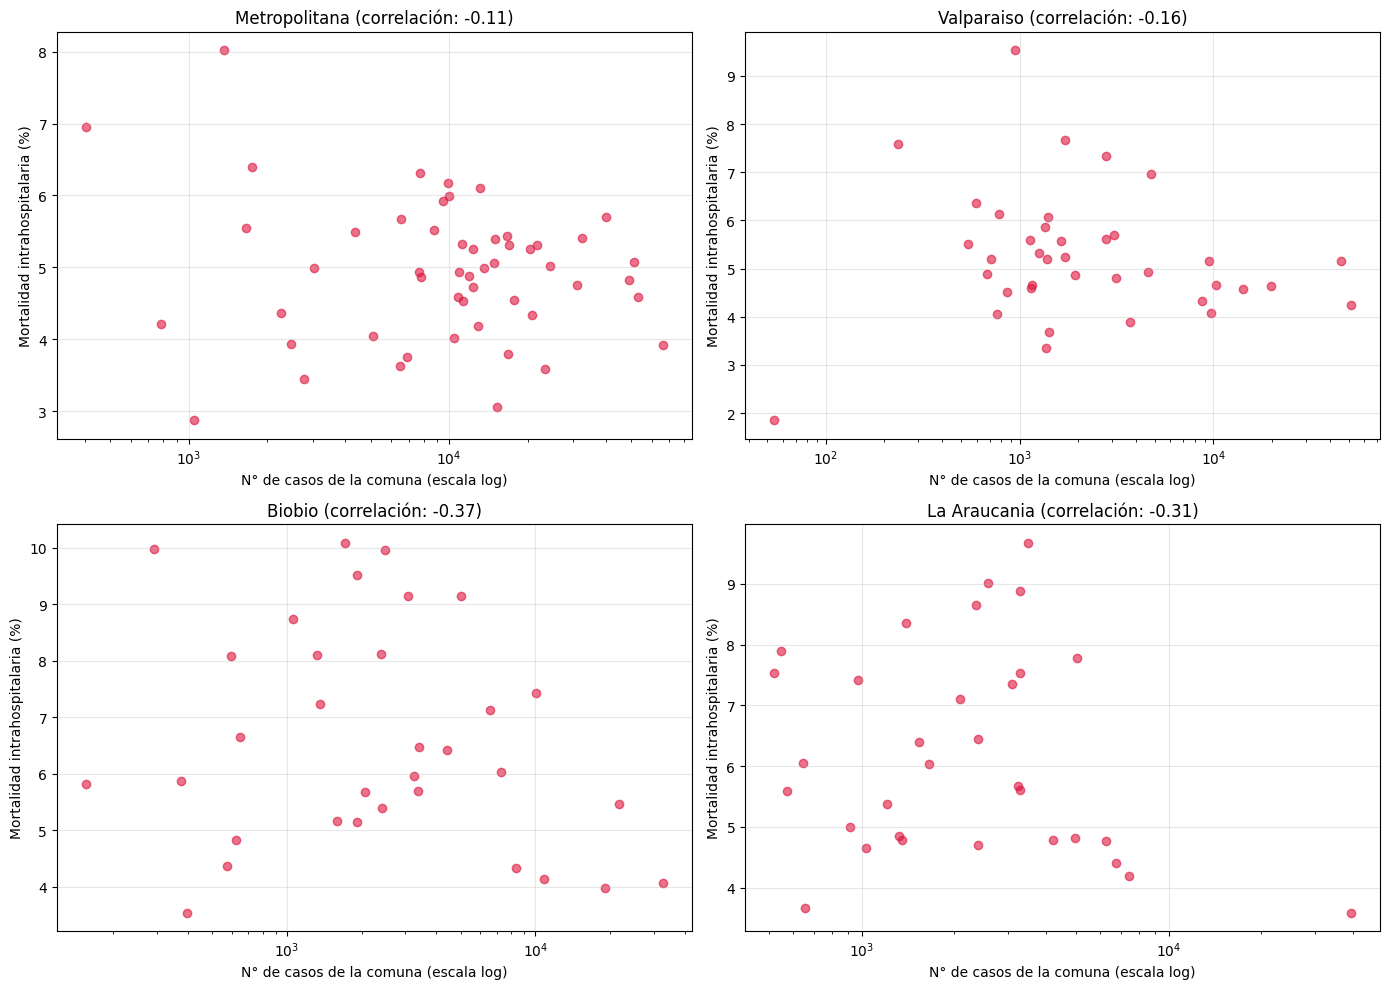

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, region in enumerate(regiones_grandes):
    df_region = df_todo[df_todo['REGION_NOMBRE'] == region]

    tabla = df_region[df_region['COMUNA_NOMBRE_LIMPIO'].notna()].groupby('COMUNA_NOMBRE_LIMPIO').agg(
        n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
        n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
    ).reset_index()
    tabla['mortalidad_intrahosp_%'] = round(100 * tabla['n_fallecidos'] / tabla['n_casos'], 2)
    tabla = tabla[tabla['n_casos'] >= 50]

    correlacion = tabla['n_casos'].corr(tabla['mortalidad_intrahosp_%'])

    axes[i].scatter(tabla['n_casos'], tabla['mortalidad_intrahosp_%'], alpha=0.6, color='crimson')
    axes[i].set_xscale('log')
    axes[i].set_xlabel('N° de casos de la comuna (escala log)')
    axes[i].set_ylabel('Mortalidad intrahospitalaria (%)')
    axes[i].set_title(f'{region} (correlación: {correlacion:.2f})')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las cuatro correlaciones son negativas, lo que indica que, dentro de las regiones analizadas, las comunas con mayor volumen de egresos hospitalarios por cáncer tienden a presentar menores tasas de mortalidad intrahospitalaria. La asociación es más marcada en Biobío (-0,37) y La Araucanía (-0,31) que en la Región Metropolitana (-0,11). Sin embargo, el volumen de egresos no constituye por sí solo una medida del tamaño poblacional, nivel de urbanización o acceso hospitalario, por lo que estas correlaciones deben interpretarse de manera descriptiva.

In [ ]:
sectores_santiago = {
    'Las Condes': 'Oriente', 'Vitacura': 'Oriente', 'Lo Barnechea': 'Oriente',
    'Providencia': 'Oriente', 'Ñuñoa': 'Oriente', 'La Reina': 'Oriente',

    'Huechuraba': 'Norte', 'Conchalí': 'Norte', 'Independencia': 'Norte',
    'Recoleta': 'Norte', 'Quilicura': 'Norte',

    'Pudahuel': 'Poniente', 'Cerro Navia': 'Poniente', 'Lo Prado': 'Poniente',
    'Quinta Normal': 'Poniente', 'Renca': 'Poniente', 'Maipú': 'Poniente',
    'Estación Central': 'Poniente',

    'La Florida': 'Sur', 'Puente Alto': 'Sur', 'San Bernardo': 'Sur',
    'La Pintana': 'Sur', 'El Bosque': 'Sur', 'La Granja': 'Sur',
    'San Ramón': 'Sur', 'La Cisterna': 'Sur',

    'Santiago': 'Centro', 'San Miguel': 'Centro', 'San Joaquín': 'Centro',
    'Macul': 'Centro', 'Peñalolén': 'Centro',
}

df_rm = df_todo[df_todo['REGION_NOMBRE'] == 'Metropolitana'].copy()
df_rm['SECTOR_SANTIAGO'] = df_rm['COMUNA_NOMBRE_LIMPIO'].map(sectores_santiago)

tabla_sector = df_rm[df_rm['SECTOR_SANTIAGO'].notna()].groupby('SECTOR_SANTIAGO').agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_sector['mortalidad_intrahosp_%'] = round(100 * tabla_sector['n_fallecidos'] / tabla_sector['n_casos'], 2)
tabla_sector = tabla_sector.sort_values('mortalidad_intrahosp_%')

print(tabla_sector.to_string(index=False))

SECTOR_SANTIAGO  n_casos  n_fallecidos  mortalidad_intrahosp_%
        Oriente   185716          7916                    4.26
       Poniente   139791          6693                    4.79
          Norte    80057          3871                    4.84
         Centro   112617          5855                    5.20
            Sur   165665          8665                    5.23


### Sectores de Santiago
Se agrupan 31 comunas seleccionadas de la Región Metropolitana en cinco sectores geográficos de uso común en Santiago. Esta categorización es de carácter exploratorio y no corresponde a una división político-administrativa oficial.

In [ ]:
UMBRAL_MINIMO_CELDA_SECTOR = 30

df_sector_edad = df_rm[
    (df_rm['SECTOR_SANTIAGO'].notna()) &
    (df_rm['GRUPO_EDAD_UNIFICADO'] != '*')
].copy()

tabla_sector_edad = df_sector_edad.groupby(['SECTOR_SANTIAGO', 'GRUPO_EDAD_UNIFICADO']).agg(
    n_casos=('MORTALIDAD_INTRAHOSP', 'size'),
    n_fallecidos=('MORTALIDAD_INTRAHOSP', 'sum')
).reset_index()

tabla_sector_edad['mortalidad_intrahosp_%'] = round(100 * tabla_sector_edad['n_fallecidos'] / tabla_sector_edad['n_casos'], 2)

pivot_sector = tabla_sector_edad.pivot(index='SECTOR_SANTIAGO', columns='GRUPO_EDAD_UNIFICADO', values='mortalidad_intrahosp_%')[orden_edad]
pivot_ncasos_sector = tabla_sector_edad.pivot(index='SECTOR_SANTIAGO', columns='GRUPO_EDAD_UNIFICADO', values='n_casos')[orden_edad]

pivot_confiable_sector = pivot_sector.where(pivot_ncasos_sector >= UMBRAL_MINIMO_CELDA_SECTOR)

print(pivot_confiable_sector.to_string())

GRUPO_EDAD_UNIFICADO  menor de 1 año  1 a 9  10 a 19  20 a 29  30 a 39  40 a 49  50 a 59  60 a 69  70 a 79  80 y más
SECTOR_SANTIAGO                                                                                                     
Centro                          3.47   0.99     1.20     2.39     2.52     3.19     4.43     5.72     7.59     12.65
Norte                           3.96   1.23     1.67     2.48     2.70     3.09     4.55     5.42     6.96     10.35
Oriente                         1.90   0.79     1.25     1.61     1.82     2.37     3.19     4.15     5.68      8.93
Poniente                        1.61   0.65     1.10     2.30     2.73     3.02     4.06     5.57     7.50     11.94
Sur                             1.29   1.10     1.72     2.35     2.73     3.10     4.25     5.73     8.04     13.23


Al estratificar por grupo de edad, el sector Oriente presenta la menor mortalidad intrahospitalaria en los diez grupos etarios analizados. La mayor brecha se observa en personas de 80 años y más, con 8,93% en Oriente frente a 13,23% en Sur, una diferencia de 4,3 puntos porcentuales. Este patrón muestra que las diferencias territoriales persisten incluso al comparar egresos dentro de los mismos grupos etarios. No obstante, dado el carácter descriptivo y agregado del análisis, estos resultados no permiten atribuir las diferencias observadas a factores específicos como la previsión de salud o el nivel socioeconómico.

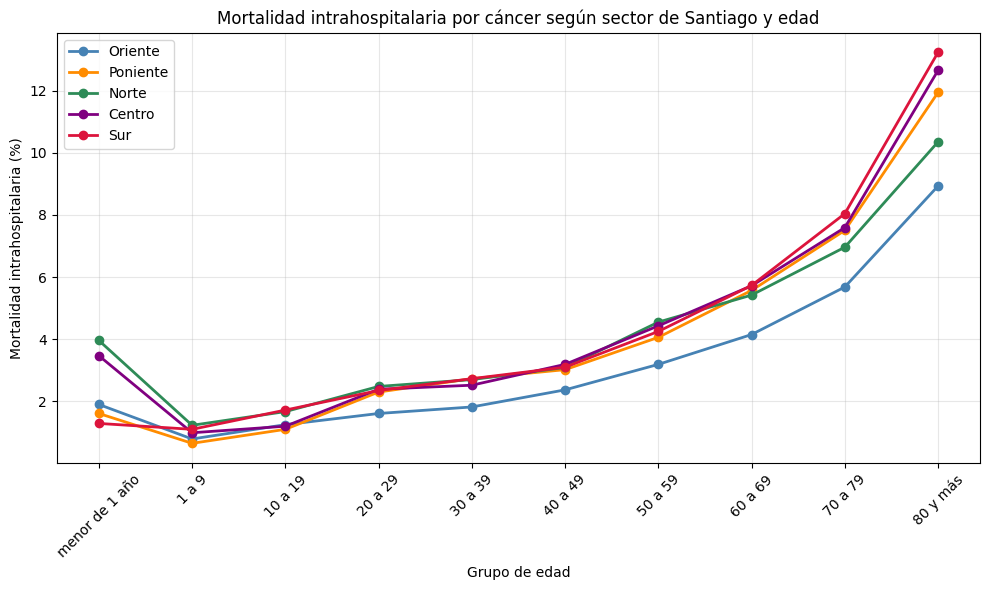

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

colores_sector = {'Oriente': 'steelblue', 'Poniente': 'darkorange', 'Norte': 'seagreen', 'Centro': 'purple', 'Sur': 'crimson'}

for sector in ['Oriente', 'Poniente', 'Norte', 'Centro', 'Sur']:
    ax.plot(orden_edad, pivot_confiable_sector.loc[sector], marker='o', linewidth=2, label=sector, color=colores_sector[sector])

ax.set_ylabel('Mortalidad intrahospitalaria (%)')
ax.set_xlabel('Grupo de edad')
ax.set_title('Mortalidad intrahospitalaria por cáncer según sector de Santiago y edad')
ax.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Síntesis final

Este notebook analiza 1.913.028 egresos hospitalarios por cáncer en Chile entre 2001 y 2025. Los resultados muestran que la edad presenta la asociación más fuerte con la mortalidad intrahospitalaria entre las variables analizadas y que existe una brecha persistente entre FONASA e ISAPRE, que aumenta con la edad. También se observan diferencias territoriales según la clasificación ambiental y la disponibilidad local de infraestructura hospitalaria, las que deben interpretarse como asociaciones descriptivas y no causales.

En el análisis predictivo se compararon regresión logística, LightGBM, XGBoost y CatBoost. Los cuatro modelos presentan un desempeño similar, con LightGBM como el de mejor capacidad discriminativa, con un AUC-ROC cercano a 0,73. Esta convergencia sugiere que la capacidad predictiva está condicionada, al menos en parte, por la información disponible en los registros administrativos.

Los análisis a nivel comunal y por sectores seleccionados de Santiago muestran además heterogeneidad territorial en las tasas de mortalidad intrahospitalaria. Finalmente, se desarrolló una interfaz interactiva en Gradio como demostración exploratoria del modelo, sin fines de decisión clínica individual.